In [6]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/competitions/shl-hiring-assessment-2026/Dataset_Final/sample_submission.csv
/kaggle/input/competitions/shl-hiring-assessment-2026/Dataset_Final/train.csv
/kaggle/input/competitions/shl-hiring-assessment-2026/Dataset_Final/test.csv
/kaggle/input/competitions/shl-hiring-assessment-2026/Dataset_Final/test/audio_49.wav
/kaggle/input/competitions/shl-hiring-assessment-2026/Dataset_Final/test/audio_90.wav
/kaggle/input/competitions/shl-hiring-assessment-2026/Dataset_Final/test/audio_77.wav
/kaggle/input/competitions/shl-hiring-assessment-2026/Dataset_Final/test/audio_66.wav
/kaggle/input/competitions/shl-hiring-assessment-2026/Dataset_Final/test/audio_54.wav
/kaggle/input/competitions/shl-hiring-assessment-2026/Dataset_Final/test/audio_42.wav
/kaggle/input/competitions/shl-hiring-assessment-2026/Dataset_Final/test/audio_81.wav
/kaggle/input/competitions/shl-hiring-assessment-2026/Dataset_Final/test/audio_72.wav
/kaggle/input/competitions/shl-hiring-assessment-2026/Dataset_Final

In [7]:
import kagglehub

# Download latest version
path = kagglehub.competition_download('shl-hiring-assessment-2026')

print("Path to competition files:", path)

Path to competition files: /kaggle/input/competitions/shl-hiring-assessment-2026


# Grammar Scoring Engine for Spoken Data

## 1. Project Overview

The objective of this project is to develop a machine learning system
that predicts a continuous grammar score between 0 and 5 from spoken
audio recordings.

The dataset contains:

- 769 labeled training audio samples
- 216 evaluation audio samples
- WAV-format speech recordings

The evaluation metrics are:

1. Pearson Correlation
2. Root Mean Squared Error (RMSE)

### Proposed Approach

Since the target represents grammar quality, the primary modeling
direction will focus on extracting linguistic information from the
speech recordings.

The planned pipeline is:

Audio → Automatic Speech Recognition → Transcript →
Text Representation → Regression Model → Grammar Score

# Imports, configuration & reproducibility

In [1]:
# ============================================================
# 1. IMPORTS & CONFIGURATION
# ============================================================

import os
import random
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")


# ------------------------------------------------------------
# Reproducibility
# ------------------------------------------------------------

SEED = 123

random.seed(SEED)
np.random.seed(SEED)


# ------------------------------------------------------------
# Display configuration
# ------------------------------------------------------------

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.width", 120)


# ------------------------------------------------------------
# Plotting configuration
# ------------------------------------------------------------

sns.set_theme(style="whitegrid")

plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 12


print("Environment initialized successfully.")
print(f"Random seed: {SEED}")

Environment initialized successfully.
Random seed: 123


# 2. Dataset Loading & Structural Validation

Before building the modeling pipeline, we first inspect the structure
of the provided dataset.

The objective of this section is to:

- Locate the training and testing CSV files
- Verify the number of samples
- Check for missing values and duplicates
- Verify that every referenced audio file exists

In [2]:
# ============================================================
# 2.1 Locate Dataset Files
# ============================================================

import os

DATA_DIR = "/kaggle/input/competitions/shl-hiring-assessment-2026"

print("Dataset directory:", os.path.abspath(DATA_DIR))

for root, dirs, files in os.walk(DATA_DIR):
    level = root.replace(DATA_DIR, "").count(os.sep)
    indent = "    " * level
    print(f"{indent}{os.path.basename(root)}/")

    for file in files[:10]:
        print(f"{indent}    {file}")

Dataset directory: /kaggle/input/competitions/shl-hiring-assessment-2026
shl-hiring-assessment-2026/
    Dataset_Final/
        sample_submission.csv
        train.csv
        test.csv
        test/
            audio_49.wav
            audio_90.wav
            audio_77.wav
            audio_66.wav
            audio_54.wav
            audio_42.wav
            audio_81.wav
            audio_72.wav
            audio_107.wav
            audio_79.wav
        train/
            audio_49.wav
            audio_663.wav
            audio_5059.wav
            audio_90.wav
            audio_581.wav
            audio_698.wav
            audio_77.wav
            audio_66.wav
            audio_555.wav
            audio_54.wav


In [3]:
# ============================================================
# 2.2 Find CSV Files
# ============================================================

csv_files = []

for root, dirs, files in os.walk(DATA_DIR):
    for file in files:
        if file.lower().endswith(".csv"):
            csv_files.append(os.path.join(root, file))

print("CSV files found:")

for path in csv_files:
    print(path)

CSV files found:
/kaggle/input/competitions/shl-hiring-assessment-2026/Dataset_Final/sample_submission.csv
/kaggle/input/competitions/shl-hiring-assessment-2026/Dataset_Final/train.csv
/kaggle/input/competitions/shl-hiring-assessment-2026/Dataset_Final/test.csv


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
# ============================================================
# 2.3 Load Training and Testing Metadata
# ============================================================

train_path = [p for p in csv_files if os.path.basename(p).lower() == "train.csv"][0]
test_path = [p for p in csv_files if os.path.basename(p).lower() == "test.csv"][0]

train_df = pd.read_csv(train_path)
test_df = pd.read_csv(test_path)

print("Training data shape:", train_df.shape)
print("Testing data shape :", test_df.shape)

Training data shape: (769, 2)
Testing data shape : (216, 2)


In [6]:
# ============================================================
# 2.5 Basic Dataset Information
# ============================================================

print("TRAINING DATA")
print("=" * 60)

train_df.info()

print("\n\nTEST DATA")
print("=" * 60)

test_df.info()

TRAINING DATA
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 769 entries, 0 to 768
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   filename  769 non-null    object 
 1   label     769 non-null    float64
dtypes: float64(1), object(1)
memory usage: 12.1+ KB


TEST DATA
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 216 entries, 0 to 215
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   filename  216 non-null    object
 1   label     216 non-null    int64 
dtypes: int64(1), object(1)
memory usage: 3.5+ KB


## 2.8 Audio File Validation

The CSV files contain the filenames corresponding to individual audio
recordings.

Before performing any audio preprocessing, we verify that:

1. Every training filename has a corresponding audio file.
2. Every test filename has a corresponding audio file.
3. There are no duplicate filenames.

In [7]:
# ============================================================
# 2.8.1 Locate Audio Files
# ============================================================

audio_files = []

for root, dirs, files in os.walk(DATA_DIR):
    for file in files:
        if file.lower().endswith(".wav"):
            audio_files.append(os.path.join(root, file))

print(f"Total WAV files found: {len(audio_files)}")

print("\nFirst 10 audio files:")
for path in audio_files[:10]:
    print(path)

Total WAV files found: 985

First 10 audio files:
/kaggle/input/competitions/shl-hiring-assessment-2026/Dataset_Final/test/audio_49.wav
/kaggle/input/competitions/shl-hiring-assessment-2026/Dataset_Final/test/audio_90.wav
/kaggle/input/competitions/shl-hiring-assessment-2026/Dataset_Final/test/audio_77.wav
/kaggle/input/competitions/shl-hiring-assessment-2026/Dataset_Final/test/audio_66.wav
/kaggle/input/competitions/shl-hiring-assessment-2026/Dataset_Final/test/audio_54.wav
/kaggle/input/competitions/shl-hiring-assessment-2026/Dataset_Final/test/audio_42.wav
/kaggle/input/competitions/shl-hiring-assessment-2026/Dataset_Final/test/audio_81.wav
/kaggle/input/competitions/shl-hiring-assessment-2026/Dataset_Final/test/audio_72.wav
/kaggle/input/competitions/shl-hiring-assessment-2026/Dataset_Final/test/audio_107.wav
/kaggle/input/competitions/shl-hiring-assessment-2026/Dataset_Final/test/audio_79.wav


In [8]:
# ============================================================
# 2.10 Label Validation
# ============================================================

print("Training label statistics:")
display(train_df["label"].describe())

print("\nUnique training labels:")
print(np.sort(train_df["label"].unique()))

print("\nTest labels:")
print(test_df["label"].unique())

Training label statistics:


count    769.000000
mean       3.313394
std        1.239000
min        0.000000
25%        2.500000
50%        3.000000
75%        4.000000
max        5.000000
Name: label, dtype: float64


Unique training labels:
[0.  1.  1.5 2.  2.5 3.  3.5 4.  4.5 5. ]

Test labels:
[-1]


In [9]:
print(train_df["label"].value_counts().sort_index())

label
0.0     37
1.0      1
1.5      3
2.0    102
2.5     79
3.0    174
3.5     64
4.0    124
4.5     52
5.0    133
Name: count, dtype: int64


# Audio EDA

In [10]:
import librosa
import librosa.display

In [11]:
# ============================================================
# 3.1 Audio Information Extraction
# ============================================================

def get_audio_info(audio_path):
    """
    Extract basic information and signal statistics from
    an audio file.
    """

    y, sr = librosa.load(
        audio_path,
        sr=None,
        mono=False
    )

    # Handle mono and stereo recordings
    if y.ndim == 1:
        channels = 1
        duration = len(y) / sr
        y_mono = y
    else:
        channels = y.shape[0]
        duration = y.shape[1] / sr
        y_mono = np.mean(y, axis=0)

    # Basic signal statistics
    rms = np.sqrt(np.mean(y_mono ** 2))
    peak_amplitude = np.max(np.abs(y_mono))

    return {
        "sample_rate": sr,
        "channels": channels,
        "duration": duration,
        "rms": rms,
        "peak_amplitude": peak_amplitude
    }

In [12]:
### path to train directory
TRAIN_AUDIO_DIR = "/kaggle/input/competitions/shl-hiring-assessment-2026/Dataset_Final/train"

In [13]:
# ============================================================
# 3.2 Extract Audio Metadata
# ============================================================

audio_metadata = []

for _, row in train_df.iterrows():

    filename = row["filename"]
    audio_path = os.path.join(TRAIN_AUDIO_DIR, filename)

    try:
        info = get_audio_info(audio_path)

        info["filename"] = filename
        info["label"] = row["label"]

        audio_metadata.append(info)

    except Exception as e:
        print(f"Error processing {filename}: {e}")

audio_df = pd.DataFrame(audio_metadata)

print("Audio metadata shape:", audio_df.shape)

display(audio_df.head())

Audio metadata shape: (769, 7)


,sample_rate,channels,duration,rms,peak_amplitude,filename,label
0,16000,1,60.508375,0.049853,0.477783,audio_192.wav,3.0
1,16000,1,60.074688,0.088254,0.945648,audio_436.wav,3.0
2,16000,1,60.074688,0.074962,0.919312,audio_447.wav,3.5
3,16000,1,45.060000,0.018400,0.328979,audio_126.wav,2.0
4,16000,1,45.300000,0.012945,0.176147,audio_61.wav,2.0


In [14]:
audio_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 769 entries, 0 to 768
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   sample_rate     769 non-null    int64  
 1   channels        769 non-null    int64  
 2   duration        769 non-null    float64
 3   rms             769 non-null    float32
 4   peak_amplitude  769 non-null    float32
 5   filename        769 non-null    object 
 6   label           769 non-null    float64
dtypes: float32(2), float64(2), int64(2), object(1)
memory usage: 36.2+ KB


In [15]:
audio_df.describe()

,sample_rate,channels,duration,rms,peak_amplitude,label
count,769.0,769.0,769.000000,769.000000,769.000000,769.000000
mean,16000.0,1.0,55.781067,0.060645,0.753278,3.313394
std,0.0,0.0,7.908964,0.027156,0.247088,1.239000
min,16000.0,1.0,20.060000,0.003577,0.038300,0.000000
25%,16000.0,1.0,54.186687,0.045300,0.637634,2.500000
50%,16000.0,1.0,60.074688,0.060206,0.844177,3.000000
75%,16000.0,1.0,60.074688,0.074587,0.945221,4.000000
max,16000.0,1.0,61.040000,0.185599,1.000000,5.000000


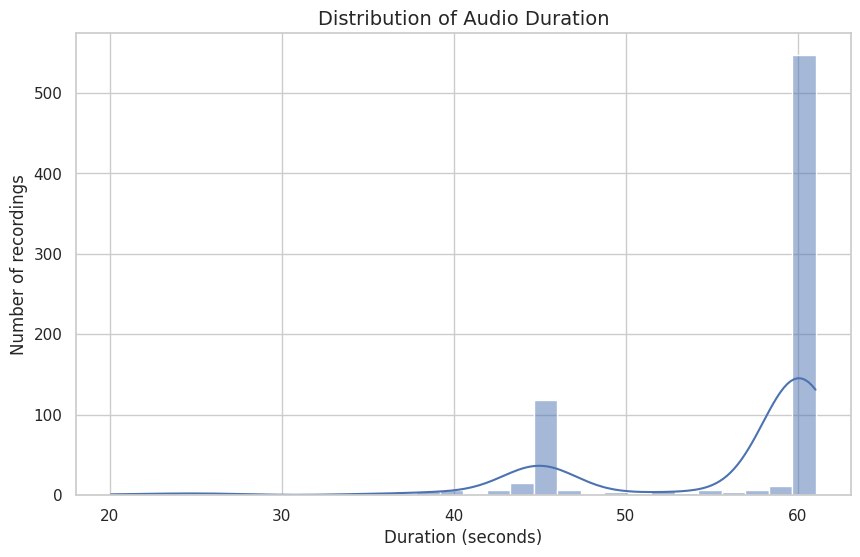

In [16]:
# ============================================================
# 3.4 Duration Distribution
# ============================================================

plt.figure(figsize=(10, 6))

sns.histplot(
    audio_df["duration"],
    bins=30,
    kde=True
)

plt.title("Distribution of Audio Duration")
plt.xlabel("Duration (seconds)")
plt.ylabel("Number of recordings")

plt.show()

##### all files are not between 45 - 60 seconds

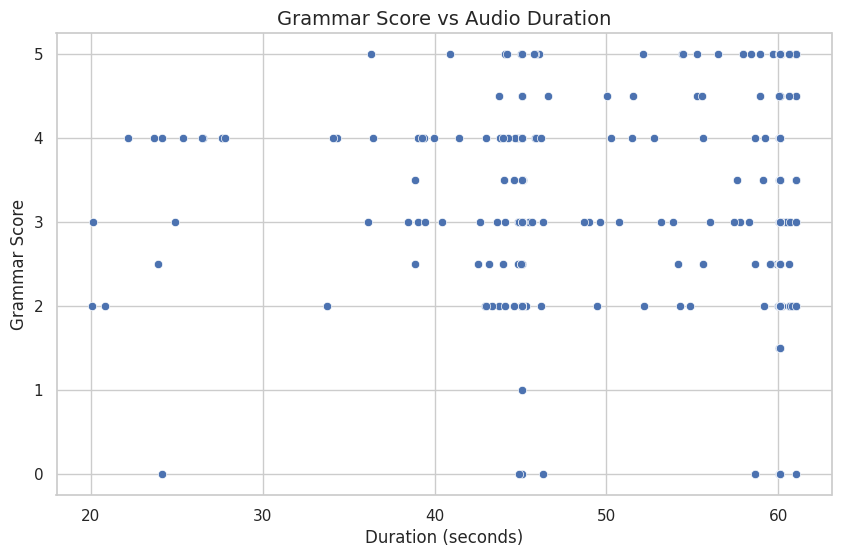

In [17]:
# ============================================================
# 3.6 Grammar Score vs Audio Duration
# ============================================================

### to check if there is a relationship between grammar score and audio distribution

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=audio_df,
    x="duration",
    y="label"
)

plt.title("Grammar Score vs Audio Duration")
plt.xlabel("Duration (seconds)")
plt.ylabel("Grammar Score")

plt.show()

In [18]:
# ============================================================
# 3.8 Correlation with Grammar Score
# ============================================================

numeric_cols = [
    "duration",
    "rms",
    "peak_amplitude",
    "label"
]

correlation_matrix = audio_df[numeric_cols].corr()

display(correlation_matrix)

,duration,rms,peak_amplitude,label
duration,1.000000,0.333411,0.494325,0.087380
rms,0.333411,1.000000,0.698385,-0.235030
peak_amplitude,0.494325,0.698385,1.000000,0.056812
label,0.087380,-0.235030,0.056812,1.000000


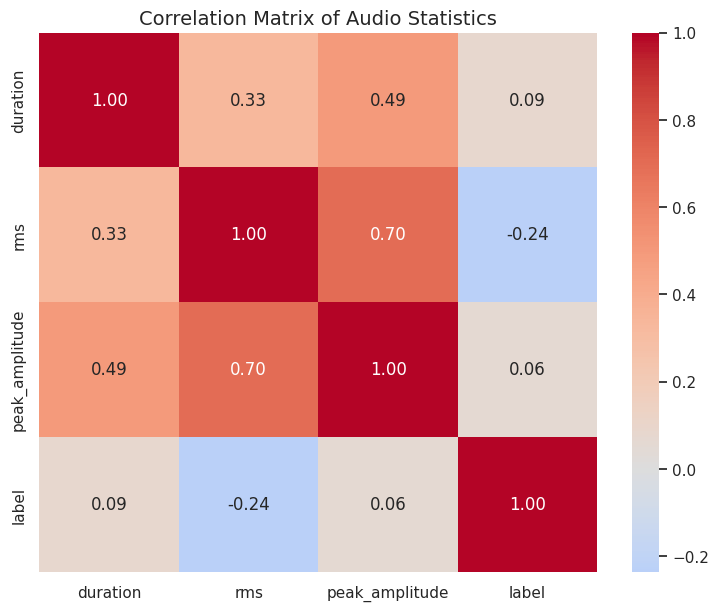

In [19]:
plt.figure(figsize=(9, 7))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Matrix of Audio Statistics")

plt.show()

### Visualizing actual Waveform

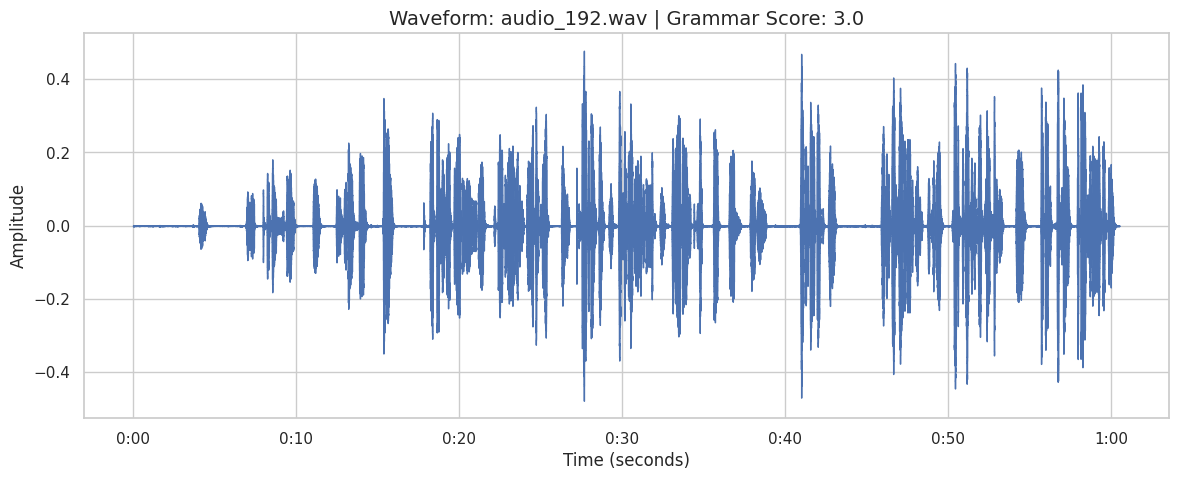

In [20]:
sample_filename = train_df.iloc[0]["filename"]

sample_path = os.path.join(
    TRAIN_AUDIO_DIR,
    sample_filename
)

y, sr = librosa.load(
    sample_path,
    sr=None,
    mono=True
)

plt.figure(figsize=(14, 5))

librosa.display.waveshow(
    y,
    sr=sr
)

plt.title(
    f"Waveform: {sample_filename} | "
    f"Grammar Score: {train_df.iloc[0]['label']}"
)

plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude")

plt.show()

# Automatic Speech Recognition

In [21]:
!pip install -q openai-whisper

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 803.2/803.2 kB 31.0 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


In [74]:
import whisper

In [75]:
import torch

device = "cuda" if torch.cuda.is_available() else "cpu"

print("Device:", device)

Device: cuda


In [76]:
# ============================================================
# 4.1 Load Whisper ASR Model
# ============================================================

model = whisper.load_model(
    "small",
    device=device
)

print("Whisper model loaded successfully.")

Whisper model loaded successfully.


In [25]:
# ============================================================
# 4.2 Test Transcription
# ============================================================

sample_filename = train_df.iloc[10]["filename"]

sample_path = os.path.join(
    TRAIN_AUDIO_DIR,
    sample_filename
)

result = model.transcribe(
    sample_path,
    language="en"
)

transcript = result["text"]

print("Filename:", sample_filename)
print("Ground-truth score:", train_df.iloc[10]["label"])
print("\nTranscript:")
print(transcript)

Filename: audio_592.wav
Ground-truth score: 5.0

Transcript:
 The journey to Switzerland is an adventure in itself whether you arrive by plane, train or car. If you fly into Zurich or Geneva you will be greeted by stunning views of Switzerland as you plane descent towards the airport. From there you can take a scenic plane ride to your destination passing through picturesque villages and rolling countryside alternatively driving through Switzerland offers the flexibility to stop at 4-5 times along the way and take in breathtaking landscape at your own pace. Whichever mode of transportation you choose to the journey to Switzerland is filled with anticipation and excitement as you anticipate the beauty that of its Swiss cuisine is there enough.


## Transcipt the whole dataset

In [26]:
# ============================================================
# 4.3 Transcribe Training Dataset
# ============================================================

train_transcripts = []

for idx, row in train_df.iterrows():

    filename = row["filename"]
    audio_path = os.path.join(
        TRAIN_AUDIO_DIR,
        filename
    )

    try:

        result = model.transcribe(
            audio_path,
            language="en"
        )

        train_transcripts.append({
            "filename": filename,
            "label": row["label"],
            "transcript": result["text"].strip()
        })

        if (idx + 1) % 25 == 0:
            print(f"Processed {idx + 1}/{len(train_df)} files")

    except Exception as e:

        print(
            f"Error processing {filename}: {e}"
        )

Processed 25/769 files
Processed 50/769 files
Processed 75/769 files
Processed 100/769 files
Processed 125/769 files
Processed 150/769 files
Processed 175/769 files
Processed 200/769 files
Processed 225/769 files
Processed 250/769 files
Processed 275/769 files
Processed 300/769 files
Processed 325/769 files
Processed 350/769 files
Processed 375/769 files
Processed 400/769 files
Processed 425/769 files
Processed 450/769 files
Processed 475/769 files
Processed 500/769 files
Processed 525/769 files
Processed 550/769 files
Processed 575/769 files
Processed 600/769 files
Processed 625/769 files
Processed 650/769 files
Processed 675/769 files
Processed 700/769 files
Processed 725/769 files
Processed 750/769 files


In [27]:
transcript_df = pd.DataFrame(train_transcripts)

print("Transcript dataframe shape:")
print(transcript_df.shape)

display(transcript_df.head())

Transcript dataframe shape:
(769, 3)


,filename,label,transcript
0,audio_192.wav,3.0,"The plate round is very, very beautiful and fu..."
1,audio_436.wav,3.0,"The scene of a school playground, our playgrou..."
2,audio_447.wav,3.5,My favorite place to visit is the beach. I lov...
3,audio_126.wav,2.0,Once upon a time we with five friends went on ...
4,audio_61.wav,2.0,"Well, when I was a child I remember I went to ..."


In [28]:
transcript_df.to_csv(
    "train_transcripts.csv",
    index=False
)

print("Transcripts saved.")

Transcripts saved.


In [29]:
transcript_df = pd.read_csv(
    "train_transcripts.csv"
)

## Transcript EDA

In [30]:
transcript_df["word_count"] = (
    transcript_df["transcript"]
    .str.split()
    .str.len()
)

display(
    transcript_df["word_count"].describe()
)

count    763.000000
mean      98.035387
std       27.121000
min        2.000000
25%       80.000000
50%       99.000000
75%      118.000000
max      156.000000
Name: word_count, dtype: float64

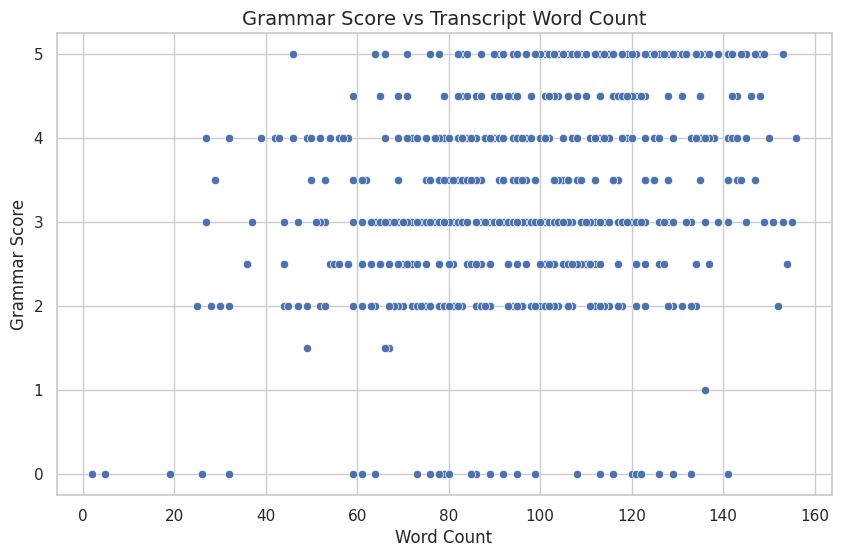

In [31]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=transcript_df,
    x="word_count",
    y="label"
)

plt.title("Grammar Score vs Transcript Word Count")
plt.xlabel("Word Count")
plt.ylabel("Grammar Score")

plt.show()

In [32]:
sample_transcripts = transcript_df.sample(
    5,
    random_state=SEED
)

for _, row in sample_transcripts.iterrows():

    print("=" * 80)
    print("Filename :", row["filename"])
    print("Score    :", row["label"])
    print("Transcript:")
    print(row["transcript"])

Filename : audio_294.wav
Score    : 4.0
Transcript:
When I think about my life, the best experience or the best day I have was worse when my kids were born. I have three kids and what makes this day special is that I was able to give birth to these beautiful human beings who are kind, sweet and lovable. When I think about those days, I just feel that I am beyond blessed to have these little people in my life. They bring happiness and joy every day, every day in my life.
Filename : audio_373.wav
Score    : 5.0
Transcript:
So the playground is fenced off bordering the school. I can hear teachers playing, excuse me, I can hear teachers sort of talking amongst themselves while the students are playing. Students are very loud or obnoxious. You can be playing tag, going through the jungle gym, what have you. Sliding down the slide, you know, trying the best to relax after just... Oh, what they find is a boring lesson in school. Maybe there's a kid being bullied somewhere too far away and the

In [33]:
print("Training samples :", len(train_df))
print("Transcripts      :", len(transcript_df))

Training samples : 769
Transcripts      : 769


In [34]:
nan_count = transcript_df["transcript"].isna().sum()
nan_percentage = transcript_df["transcript"].isna().mean() * 100

print(f"NaN transcripts: {nan_count}")
## & transcripts are nan

NaN transcripts: 6


In [35]:
nan_transcripts = transcript_df[
    transcript_df["transcript"].isna()
]

print(f"Number of NaN transcripts: {len(nan_transcripts)}")

display(nan_transcripts)

Number of NaN transcripts: 6


,filename,label,transcript,word_count
41,audio_5069.wav,0.0,NaN,NaN
73,audio_5056.wav,0.0,NaN,NaN
374,audio_5058.wav,0.0,NaN,NaN
458,audio_5049.wav,0.0,NaN,NaN
485,audio_5042.wav,0.0,NaN,NaN
501,audio_5060.wav,0.0,NaN,NaN


In [36]:
nan_files = nan_transcripts["filename"].tolist()

print(nan_files)

['audio_5069.wav', 'audio_5056.wav', 'audio_5058.wav', 'audio_5049.wav', 'audio_5042.wav', 'audio_5060.wav']


In [37]:
noise_files = [
    "audio_5069.wav",
    "audio_5056.wav",
    "audio_5058.wav",
    "audio_5049.wav",
    "audio_5042.wav",
    "audio_5060.wav"
]

print(f"Noise-only samples identified: {len(noise_files)}")

Noise-only samples identified: 6


In [38]:
noise_df = train_df[
    train_df["filename"].isin(noise_files)
].copy()

display(noise_df)

,filename,label
41,audio_5069.wav,0.0
73,audio_5056.wav,0.0
374,audio_5058.wav,0.0
458,audio_5049.wav,0.0
485,audio_5042.wav,0.0
501,audio_5060.wav,0.0


In [39]:
clean_train_df = train_df[
    ~train_df["filename"].isin(noise_files)
].copy()

clean_train_df = clean_train_df.reset_index(drop=True)

print("Original training samples :", len(train_df))
print("Noise-only samples        :", len(noise_files))
print("Clean training samples    :", len(clean_train_df))

Original training samples : 769
Noise-only samples        : 6
Clean training samples    : 763


In [40]:
clean_transcript_df = transcript_df[
    ~transcript_df["filename"].isin(noise_files)
].copy()

clean_transcript_df = clean_transcript_df.reset_index(drop=True)

print("Clean transcript samples:", len(clean_transcript_df))

Clean transcript samples: 763


### Data Quality Screening

During the ASR preprocessing stage, seven training recordings were
identified as containing noise without usable speech content.

Whisper produced empty transcripts for these recordings. Manual
inspection of the corresponding audio confirmed that they contained
noise rather than speech.

Since the objective is to predict grammar quality from spoken
language, these recordings do not contain the linguistic information
required for the task. They were therefore excluded from the modeling
dataset.

Original training samples: 769
Noise-only samples removed: 7
Final modeling samples: 762

### Basic Statistics

In [41]:
clean_transcript_df.describe()

,label,word_count
count,763.000000,763.000000
mean,3.339450,98.035387
std,1.208339,27.121000
min,0.000000,2.000000
25%,2.500000,80.000000
50%,3.000000,99.000000
75%,4.000000,118.000000
max,5.000000,156.000000


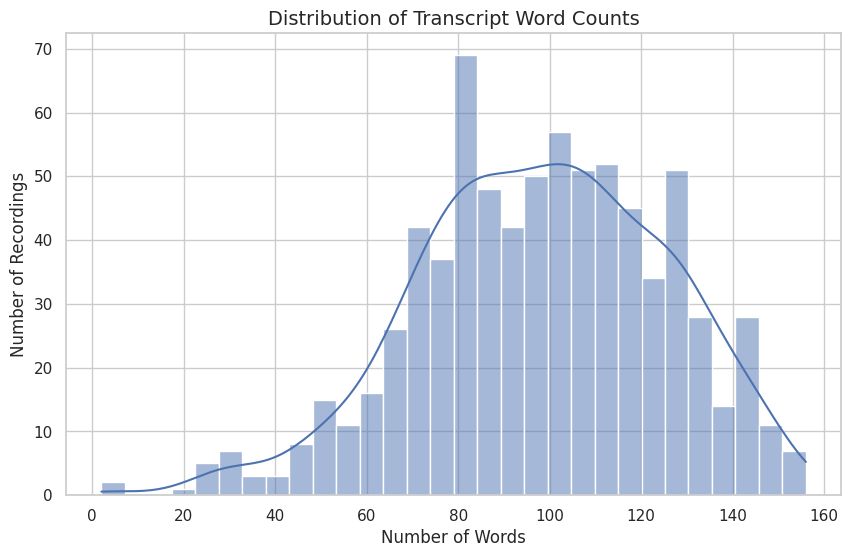

In [42]:
### Transcript length distribution

plt.figure(figsize=(10, 6))

sns.histplot(
    clean_transcript_df["word_count"],
    bins=30,
    kde=True
)

plt.title("Distribution of Transcript Word Counts")
plt.xlabel("Number of Words")
plt.ylabel("Number of Recordings")

plt.show()

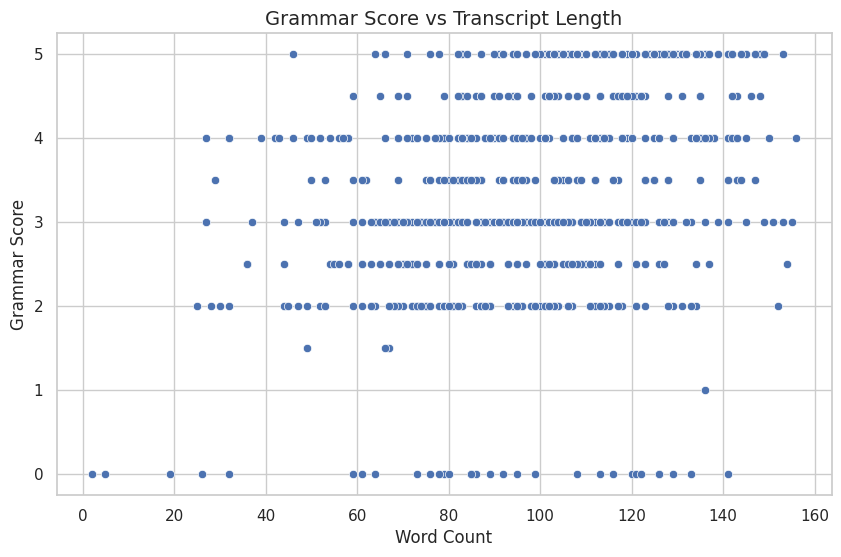

In [43]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=clean_transcript_df,
    x="word_count",
    y="label"
)

plt.title("Grammar Score vs Transcript Length")
plt.xlabel("Word Count")
plt.ylabel("Grammar Score")

plt.show()

In [44]:
# ============================================================
# 5.3 Merge Audio Metadata
# ============================================================

clean_transcript_df = clean_transcript_df.merge(
    audio_df[["filename", "duration"]],
    on="filename",
    how="left"
)

clean_transcript_df["words_per_minute"] = (
    clean_transcript_df["word_count"]
    / clean_transcript_df["duration"]
    * 60
)

display(
    clean_transcript_df[
        ["filename", "word_count",
         "duration", "words_per_minute", "label"]
    ].head()
)

,filename,word_count,duration,words_per_minute,label
0,audio_192.wav,95.0,60.508375,94.201836,3.0
1,audio_436.wav,109.0,60.074688,108.864486,3.0
2,audio_447.wav,147.0,60.074688,146.817243,3.5
3,audio_126.wav,86.0,45.060000,114.513981,2.0
4,audio_61.wav,78.0,45.300000,103.311258,2.0


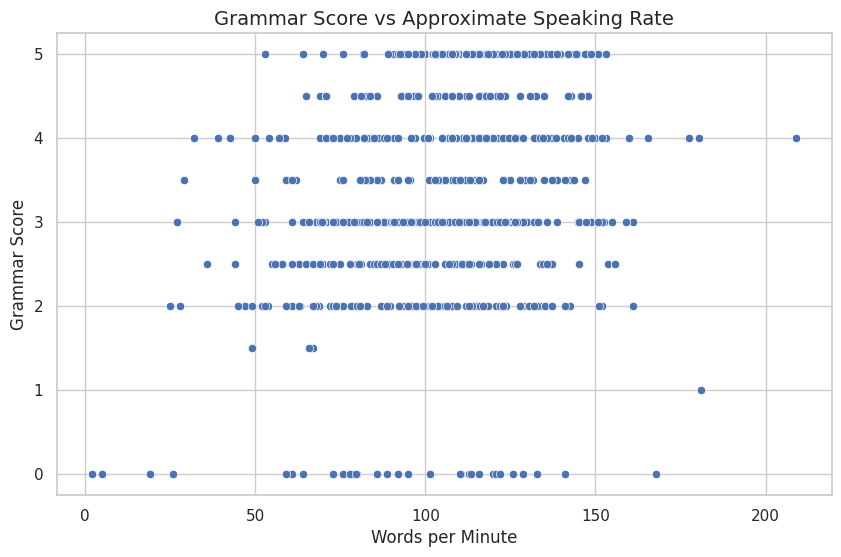

In [45]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=clean_transcript_df,
    x="words_per_minute",
    y="label"
)

plt.title("Grammar Score vs Approximate Speaking Rate")
plt.xlabel("Words per Minute")
plt.ylabel("Grammar Score")

plt.show()

In [46]:
print("LOW SCORE EXAMPLES")
print("=" * 80)

low_scores = (
    clean_transcript_df
    .sort_values("label")
    .head(3)
)

for _, row in low_scores.iterrows():

    print(f"Score: {row['label']}")
    print(f"Transcript: {row['transcript']}")
    print("-" * 80)

LOW SCORE EXAMPLES
Score: 0.0
Transcript: The proof playground with you
--------------------------------------------------------------------------------
Score: 0.0
Transcript: I'm going to tell you about this thing at the product market. The product market is full of people and selling and buying these vegetables or vegetables. In the market, there is a kind of exchange of people through the both currency, selling and buying. The best thing is to be cautious on your own. But the sounds which they say that these are the vegetables you can buy, these are the vegetables that are available. These are the sounds which can be heard in the market. And those sounds are even audible in the lower-on. The product market's skin changes day by day from the morning to the evening. In the morning, the product changes and the skin, the productings, the markings, those are the things that change.
--------------------------------------------------------------------------------
Score: 0.0
Transcript: My 

In [47]:
print("HIGH SCORE EXAMPLES")
print("=" * 80)

high_scores = (
    clean_transcript_df
    .sort_values("label", ascending=False)
    .head(3)
)

for _, row in high_scores.iterrows():

    print(f"Score: {row['label']}")
    print(f"Transcript: {row['transcript']}")
    print("-" * 80)

HIGH SCORE EXAMPLES
Score: 5.0
Transcript: The journey to Switzerland is an adventure in itself whether you arrive by plane, train or car. If you fly into Zurich or Geneva you will be greeted by stunning views of Switzerland as you plane descent towards the airport. From there you can take a scenic plane ride to your destination passing through picturesque villages and rolling countryside alternatively driving through Switzerland offers the flexibility to stop at 4-5 times along the way and take in breathtaking landscape at your own pace. Whichever mode of transportation you choose to the journey to Switzerland is filled with anticipation and excitement as you anticipate the beauty that of its Swiss cuisine is there enough.
--------------------------------------------------------------------------------
Score: 5.0
Transcript: my best day I've ever had is every time I've been at Disney I enjoy the decoration and the rides I think what makes this day special is all the planning that goes

# 6. Baseline Modeling

We establish simple baselines before experimenting with
advanced text representations.

The primary evaluation metrics are:

- Pearson Correlation: measures the linear association between
  predicted and ground-truth grammar scores.
- RMSE: measures the magnitude of prediction errors.

All subsequent models will be evaluated using the same metrics
and validation strategy.

In [54]:
# ============================================================
# 6.1 Evaluation Metrics
# ============================================================

from sklearn.metrics import mean_squared_error
from scipy.stats import pearsonr


def evaluate_model(y_true, y_pred):
    """
    Calculate RMSE and Pearson correlation.
    """
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    rmse = np.sqrt(mean_squared_error(y_true, y_pred))

    # Pearson is undefined if predictions are constant (zero spread)
    if np.std(y_pred) == 0:
        pearson = 0.0
    else:
        pearson = pearsonr(y_true, y_pred)[0]

    return rmse, pearson

In [55]:
# ============================================================
# 6.2 Prepare Modeling Data
# ============================================================

X_text = clean_transcript_df["transcript"]

y = clean_transcript_df["label"]

print("Number of samples:", len(X_text))
print("Number of targets:", len(y))

Number of samples: 763
Number of targets: 763


In [56]:
# ============================================================
# 6.3 Train/Validation Split
# ============================================================

from sklearn.model_selection import train_test_split

X_train, X_valid, y_train, y_valid = train_test_split(
    X_text,
    y,
    test_size=0.20,
    random_state=SEED
)

print("Training samples  :", len(X_train))
print("Validation samples:", len(X_valid))

Training samples  : 610
Validation samples: 153


# Baseline Mean Prediction

In [57]:
# ============================================================
# 6.4 Mean Baseline
# ============================================================

mean_score = y_train.mean()

baseline_predictions = np.full(len(y_valid), mean_score)

baseline_rmse, baseline_pearson = evaluate_model(y_valid, baseline_predictions)

print(f"Mean training score: {mean_score:.4f}")
print(f"RMSE: {baseline_rmse:.4f}")
print(f"Pearson: {baseline_pearson:.4f}")

Mean training score: 3.3385
RMSE: 1.2738
Pearson: nan


### Baseline 2 - TF-IDF + Ridge

In [58]:
# ============================================================
# 6.5 TF-IDF + Ridge Regression
# ============================================================

from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import Ridge

tfidf_ridge = Pipeline([
    
    (
        "tfidf",
        TfidfVectorizer(
            lowercase=True,
            ngram_range=(1, 2),
            min_df=2,
            max_df=0.95,
            sublinear_tf=True
        )
    ),

    (
        "ridge",
        Ridge(alpha=10.0)
    )
])

In [59]:
# ============================================================
# 6.6 Train TF-IDF + Ridge
# ============================================================

tfidf_ridge.fit(
    X_train,
    y_train
)

print("TF-IDF + Ridge training completed.")

TF-IDF + Ridge training completed.


In [60]:
# ============================================================
# 6.7 Validation Predictions
# ============================================================

tfidf_predictions = tfidf_ridge.predict(
    X_valid
)

# Grammar score is constrained to 0–5
tfidf_predictions = np.clip(
    tfidf_predictions,
    0,
    5
)

In [61]:
# ============================================================
# 6.8 Evaluate TF-IDF + Ridge
# ============================================================

tfidf_rmse, tfidf_pearson = evaluate_model(y_valid, tfidf_predictions)

print(f"RMSE: {tfidf_rmse:.4f}")
print(f"Pearson: {tfidf_pearson:.4f}")

RMSE: 1.2027
Pearson: 0.5948


In [62]:
from sklearn.model_selection import KFold, cross_val_score
from sklearn.metrics import root_mean_squared_error

def rmse_scorer(estimator, X, y):
    predictions = estimator.predict(X)
    predictions = np.clip(predictions, 0, 5)

    return root_mean_squared_error(y, predictions)

### 5-Fold cross validation 

In [63]:
alphas = [0.01, 0.1, 1, 10, 100, 1000]

kf = KFold(n_splits=5, shuffle=True, random_state=SEED)

results = []

for alpha in alphas:

    model = Pipeline([
        (
            "tfidf",
            TfidfVectorizer(
                lowercase=True,
                ngram_range=(1, 2),
                min_df=2,
                max_df=0.95,
                sublinear_tf=True
            )
        ),
        (
            "ridge",
            Ridge(alpha=alpha)
        )
    ])

    fold_rmses = []
    fold_pearsons = []

    for train_idx, val_idx in kf.split(X_train):

        X_tr = X_train.iloc[train_idx]
        X_val = X_train.iloc[val_idx]

        y_tr = y_train.iloc[train_idx]
        y_val = y_train.iloc[val_idx]

        model.fit(X_tr, y_tr)

        predictions = model.predict(X_val)
        predictions = np.clip(predictions, 0, 5)

        # evaluate_model returns (rmse, pearson)
        rmse, pearson = evaluate_model(y_val, predictions)

        fold_rmses.append(rmse)
        fold_pearsons.append(pearson)

    results.append({
        "alpha": alpha,
        "mean_cv_rmse": np.mean(fold_rmses),
        "std_cv_rmse": np.std(fold_rmses),
        "mean_cv_pearson": np.mean(fold_pearsons),
        "std_cv_pearson": np.std(fold_pearsons)
    })

rmse_results = pd.DataFrame(results)

rmse_results = rmse_results.sort_values("mean_cv_rmse").reset_index(drop=True)

display(rmse_results)

,alpha,mean_cv_rmse,std_cv_rmse,mean_cv_pearson,std_cv_pearson
0,1.00,1.065966,0.047923,0.464890,0.081180
1,0.10,1.091532,0.053737,0.429052,0.083068
2,0.01,1.112692,0.052549,0.412461,0.080315
3,10.00,1.141443,0.040694,0.461296,0.067397
4,100.00,1.184279,0.040065,0.446736,0.058491
5,1000.00,1.190298,0.040011,0.444249,0.057140


In [64]:
best_alpha = rmse_results.iloc[0]["alpha"]
best_rmse = rmse_results.iloc[0]["mean_cv_rmse"]

print(f"Best alpha: {best_alpha}")
print(f"Best CV RMSE: {best_rmse:.4f}")

Best alpha: 1.0
Best CV RMSE: 1.0660


In [68]:
test_df = pd.read_csv(test_path)

print("Test shape:", test_df.shape)
display(test_df.head())

Test shape: (216, 2)


,filename,label
0,audio_128.wav,-1
1,audio_156.wav,-1
2,audio_19.wav,-1
3,audio_108.wav,-1
4,audio_206.wav,-1


In [71]:
DATA_DIR = "/kaggle/input/competitions/shl-hiring-assessment-2026/Dataset_Final"
TEST_AUDIO_DIR = os.path.join(DATA_DIR, "test")

In [72]:
test_audio_files = os.listdir(TEST_AUDIO_DIR)

print("Number of test audio files:", len(test_audio_files))
print("First 10 files:", test_audio_files[:10])

Number of test audio files: 216
First 10 files: ['audio_49.wav', 'audio_90.wav', 'audio_77.wav', 'audio_66.wav', 'audio_54.wav', 'audio_42.wav', 'audio_81.wav', 'audio_72.wav', 'audio_107.wav', 'audio_79.wav']


In [77]:
TEST_TRANSCRIPT_FILE = "test_transcripts.csv"

if os.path.exists(TEST_TRANSCRIPT_FILE):
    test_transcript_df = pd.read_csv(TEST_TRANSCRIPT_FILE)
    processed_test_files = set(test_transcript_df["filename"])
    
    print(f"Loaded {len(test_transcript_df)} existing transcripts.")
else:
    test_transcript_df = pd.DataFrame(
        columns=["filename", "transcript"]
    )
    processed_test_files = set()


for _, row in test_df.iterrows():

    filename = row["filename"]

    # Skip files already processed
    if filename in processed_test_files:
        continue

    audio_path = os.path.join(TEST_AUDIO_DIR, filename)

    try:
        result = model.transcribe(
            audio_path,
            language="en"
        )

        transcript = result["text"].strip()

        new_row = pd.DataFrame([{
            "filename": filename,
            "transcript": transcript
        }])

        test_transcript_df = pd.concat(
            [test_transcript_df, new_row],
            ignore_index=True
        )

        # Save progress after every file
        test_transcript_df.to_csv(
            TEST_TRANSCRIPT_FILE,
            index=False
        )

        if len(test_transcript_df) % 10 == 0:
            print(
                f"Processed {len(test_transcript_df)}/{len(test_df)}"
            )

    except Exception as e:
        print(f"Error processing {filename}: {e}")

Processed 10/216
Processed 20/216
Processed 30/216
Processed 40/216
Processed 50/216
Processed 60/216
Processed 70/216
Processed 80/216
Processed 90/216
Processed 100/216
Processed 110/216
Processed 120/216
Processed 130/216
Processed 140/216
Processed 150/216
Processed 160/216
Processed 170/216
Processed 180/216
Processed 190/216
Processed 200/216
Processed 210/216


In [78]:
test_transcript_df.to_csv("test_transcript.csv")

In [79]:
# Keep the exact ordering from test.csv
test_data = test_df[["filename"]].merge(
    test_transcript_df[["filename", "transcript"]],
    on="filename",
    how="left"
)

print("Test samples:", len(test_data))
print("Missing transcripts:", test_data["transcript"].isna().sum())

display(test_data.head())

Test samples: 216
Missing transcripts: 0


,filename,transcript
0,audio_128.wav,The moment in my life that I cherish the most ...
1,audio_156.wav,One of the role models is someone who embodies...
2,audio_19.wav,"I guess my favorite sport would be taekwondo, ..."
3,audio_108.wav,Hospital having more doctors and there are so ...
4,audio_206.wav,I remember once upon a time when I went to Goa...


In [80]:
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import Ridge

final_baseline_model = Pipeline([
    (
        "tfidf",
        TfidfVectorizer(
            lowercase=True,
            ngram_range=(1, 2),
            min_df=2,
            max_df=0.95,
            sublinear_tf=True
        )
    ),
    (
        "ridge",
        Ridge(alpha=best_alpha)
    )
])

final_baseline_model.fit(
    clean_transcript_df["transcript"],
    clean_transcript_df["label"]
)

print("Final baseline model trained.")
print("Training samples:", len(clean_transcript_df))
print("Best alpha:", best_alpha)

Final baseline model trained.
Training samples: 763
Best alpha: 1.0


In [81]:
test_predictions = final_baseline_model.predict(
    test_data["transcript"]
)

# Grammar scores are constrained to 0–5
test_predictions = np.clip(
    test_predictions,
    0,
    5
)

print("Number of predictions:", len(test_predictions))
print("Minimum prediction:", test_predictions.min())
print("Maximum prediction:", test_predictions.max())
print("Mean prediction:", test_predictions.mean())

Number of predictions: 216
Minimum prediction: 2.136625191318949
Maximum prediction: 4.665109841906995
Mean prediction: 3.2973349162791115


In [126]:
submission = pd.DataFrame({
    "filename": test_data["filename"],
    "label": test_predictions
})

submission.to_csv(
    "/kaggle/working/submission.csv",
    index=False
)

print("submission.csv created successfully!")

submission.csv created successfully!


In [124]:
print("Shape:", submission.shape)
print("\nColumns:", submission.columns.tolist())

print("\nMissing values:")
print(submission.isna().sum())

print("\nFirst 10 predictions:")
display(submission.head(10))

print("\nPrediction statistics:")
display(submission["label"].describe())

Shape: (216, 2)

Columns: ['filename', 'label']

Missing values:
filename    0
label       0
dtype: int64

First 10 predictions:


,filename,label
0,audio_128.wav,2.775846
1,audio_156.wav,3.643939
2,audio_19.wav,4.126873
3,audio_108.wav,2.920534
4,audio_206.wav,2.729792
5,audio_161.wav,3.708803
6,audio_215.wav,3.087581
7,audio_213.wav,3.022869
8,audio_11.wav,3.337284
9,audio_155.wav,3.604286



Prediction statistics:


count    216.000000
mean       3.287355
std        0.423020
min        2.257956
25%        2.971219
50%        3.320547
75%        3.540703
max        4.595267
Name: label, dtype: float64

### Sentence-Transformer embeddings

In [82]:
!pip install -q sentence-transformers

In [83]:
from sentence_transformers import SentenceTransformer
from sklearn.linear_model import Ridge
from sklearn.model_selection import KFold
from sklearn.metrics import root_mean_squared_error
import numpy as np
import pandas as pd

In [84]:
embedding_model = SentenceTransformer(
    "all-mpnet-base-v2"
)

print("Embedding model loaded.")

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/571 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Embedding model loaded.


In [85]:
import torch

device = "cuda" if torch.cuda.is_available() else "cpu"

embedding_model = SentenceTransformer(
    "all-mpnet-base-v2",
    device=device
)

print("Device:", device)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

MPNetModel LOAD REPORT from: sentence-transformers/all-mpnet-base-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Device: cuda


In [86]:
train_texts = clean_transcript_df["transcript"].tolist()

train_embeddings = embedding_model.encode(
    train_texts,
    batch_size=32,
    show_progress_bar=True,
    convert_to_numpy=True,
    normalize_embeddings=True
)

print("Embedding shape:", train_embeddings.shape)

Batches:   0%|          | 0/24 [00:00<?, ?it/s]

Embedding shape: (763, 768)


In [87]:
np.save(
    "train_mpnet_embeddings.npy",
    train_embeddings
)

In [88]:
indices = np.arange(len(clean_transcript_df))

train_idx, valid_idx = train_test_split(
    indices,
    test_size=0.20,
    random_state=SEED
)

X_emb_train = train_embeddings[train_idx]
X_emb_valid = train_embeddings[valid_idx]

y_emb_train = clean_transcript_df.iloc[train_idx]["label"].values
y_emb_valid = clean_transcript_df.iloc[valid_idx]["label"].values

### First embedding Model

In [89]:
embedding_ridge = Ridge(alpha=1)

embedding_ridge.fit(X_emb_train, y_emb_train)

embedding_predictions = embedding_ridge.predict(X_emb_valid)
embedding_predictions = np.clip(embedding_predictions, 0, 5)

# evaluate_model returns (rmse, pearson)
embedding_rmse, embedding_pearson = evaluate_model(y_emb_valid, embedding_predictions)

print(f"Sentence Embedding + Ridge RMSE: {embedding_rmse:.4f}")
print(f"Sentence Embedding + Ridge Pearson: {embedding_pearson:.4f}")

Sentence Embedding + Ridge RMSE: 0.9870
Sentence Embedding + Ridge Pearson: 0.6541


In [91]:
embedding_alphas = [0.001, 0.01, 0.1, 1, 10, 100, 1000]

embedding_results = []

for alpha in embedding_alphas:

    model = Ridge(alpha=alpha)
    model.fit(X_emb_train, y_emb_train)

    predictions = model.predict(X_emb_valid)

    # Grammar score must lie between 0 and 5
    predictions = np.clip(predictions, 0, 5)

    # evaluate_model returns (rmse, pearson)
    rmse, pearson = evaluate_model(y_emb_valid, predictions)

    embedding_results.append({
        "alpha": alpha,
        "validation_rmse": rmse,
        "validation_pearson": pearson
    })


embedding_results_df = (
    pd.DataFrame(embedding_results)
    .sort_values("validation_rmse")
    .reset_index(drop=True)
)

display(embedding_results_df)

,alpha,validation_rmse,validation_pearson
0,1.000,0.987000,0.654098
1,0.100,1.000053,0.621682
2,10.000,1.097381,0.598402
3,0.010,1.141121,0.534702
4,100.000,1.232976,0.454861
5,1000.000,1.268814,0.396929
6,0.001,1.552896,0.333272


In [92]:
df = embedding_results_df.copy()

# rank 1 = best for each metric
df["rmse_rank"] = df["validation_rmse"].rank(ascending=True)       # lower RMSE is better
df["pearson_rank"] = df["validation_pearson"].rank(ascending=False) # higher Pearson is better
df["avg_rank"] = (df["rmse_rank"] + df["pearson_rank"]) / 2

df = df.sort_values("avg_rank").reset_index(drop=True)
display(df)

best_embedding_alpha = df.iloc[0]["alpha"]
best_embedding_rmse = df.iloc[0]["validation_rmse"]
best_embedding_pearson = df.iloc[0]["validation_pearson"]

print("Best alpha:", best_embedding_alpha)
print(f"Best validation RMSE: {best_embedding_rmse:.4f}")
print(f"Best validation Pearson: {best_embedding_pearson:.4f}")

,alpha,validation_rmse,validation_pearson,rmse_rank,pearson_rank,avg_rank
0,1.000,0.987000,0.654098,1.0,1.0,1.0
1,0.100,1.000053,0.621682,2.0,2.0,2.0
2,10.000,1.097381,0.598402,3.0,3.0,3.0
3,0.010,1.141121,0.534702,4.0,4.0,4.0
4,100.000,1.232976,0.454861,5.0,5.0,5.0
5,1000.000,1.268814,0.396929,6.0,6.0,6.0
6,0.001,1.552896,0.333272,7.0,7.0,7.0


Best alpha: 1.0
Best validation RMSE: 0.9870
Best validation Pearson: 0.6541


In [93]:
# Generate MPNet embeddings for the test transcripts

test_embeddings = embedding_model.encode(
    test_data["transcript"].tolist(),
    batch_size=32,
    show_progress_bar=True,
    convert_to_numpy=True,
    normalize_embeddings=True
)

print("Test embedding shape:", test_embeddings.shape)

Batches:   0%|          | 0/7 [00:00<?, ?it/s]

Test embedding shape: (216, 768)


In [94]:
np.save(
    "test_mpnet_embeddings.npy",
    test_embeddings
)

### roberta -v embeddings

In [97]:
from sentence_transformers import SentenceTransformer

roberta_model = SentenceTransformer(
    "all-roberta-large-v1",
    device=device
)

print("RoBERTa sentence embedding model loaded.")

Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: sentence-transformers/all-roberta-large-v1
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


RoBERTa sentence embedding model loaded.


In [96]:
roberta_train_embeddings = roberta_model.encode(
    clean_transcript_df["transcript"].tolist(),
    batch_size=16,
    show_progress_bar=True,
    convert_to_numpy=True,
    normalize_embeddings=True
)

print(
    "Training embedding shape:",
    roberta_train_embeddings.shape
)

Batches:   0%|          | 0/48 [00:00<?, ?it/s]

Training embedding shape: (763, 1024)


In [98]:
np.save(
    "train_roberta_embeddings.npy",
    roberta_train_embeddings
)

In [99]:
X_roberta_train = roberta_train_embeddings[train_idx]
X_roberta_valid = roberta_train_embeddings[valid_idx]

y_roberta_train = clean_transcript_df.iloc[train_idx]["label"].values
y_roberta_valid = clean_transcript_df.iloc[valid_idx]["label"].values

In [100]:
roberta_alphas = [0.001, 0.01, 0.1, 1, 10, 100, 1000]

roberta_results = []

for alpha in roberta_alphas:

    model = Ridge(alpha=alpha)
    model.fit(X_roberta_train, y_roberta_train)

    predictions = model.predict(X_roberta_valid)
    predictions = np.clip(predictions, 0, 5)

    # evaluate_model returns (rmse, pearson)
    rmse, pearson = evaluate_model(y_roberta_valid, predictions)

    roberta_results.append({
        "alpha": alpha,
        "validation_rmse": rmse,
        "validation_pearson": pearson
    })

roberta_results_df = (
    pd.DataFrame(roberta_results)
    .sort_values("validation_rmse")
    .reset_index(drop=True)
)

display(roberta_results_df)

,alpha,validation_rmse,validation_pearson
0,1.000,0.933434,0.695637
1,0.100,0.949416,0.671249
2,10.000,1.076256,0.627543
3,0.010,1.134455,0.578571
4,100.000,1.229085,0.498912
5,1000.000,1.268431,0.448460
6,0.001,1.435544,0.444032


In [101]:
df = roberta_results_df.copy()

df["rmse_rank"] = df["validation_rmse"].rank(ascending=True)         # lower is better
df["pearson_rank"] = df["validation_pearson"].rank(ascending=False)  # higher is better
df["avg_rank"] = (df["rmse_rank"] + df["pearson_rank"]) / 2

# break ties using lower RMSE
df = df.sort_values(["avg_rank", "validation_rmse"]).reset_index(drop=True)
display(df)

best_roberta_alpha = df.iloc[0]["alpha"]
best_roberta_rmse = df.iloc[0]["validation_rmse"]
best_roberta_pearson = df.iloc[0]["validation_pearson"]

print("Best alpha:", best_roberta_alpha)
print(f"Best validation RMSE: {best_roberta_rmse:.4f}")
print(f"Best validation Pearson: {best_roberta_pearson:.4f}")

,alpha,validation_rmse,validation_pearson,rmse_rank,pearson_rank,avg_rank
0,1.000,0.933434,0.695637,1.0,1.0,1.0
1,0.100,0.949416,0.671249,2.0,2.0,2.0
2,10.000,1.076256,0.627543,3.0,3.0,3.0
3,0.010,1.134455,0.578571,4.0,4.0,4.0
4,100.000,1.229085,0.498912,5.0,5.0,5.0
5,1000.000,1.268431,0.448460,6.0,6.0,6.0
6,0.001,1.435544,0.444032,7.0,7.0,7.0


Best alpha: 1.0
Best validation RMSE: 0.9334
Best validation Pearson: 0.6956


In [102]:
roberta_test_embeddings = roberta_model.encode(
    test_data["transcript"].tolist(),
    batch_size=16,
    show_progress_bar=True,
    convert_to_numpy=True,
    normalize_embeddings=True
)

print("Test embedding shape:", roberta_test_embeddings.shape)

Batches:   0%|          | 0/14 [00:00<?, ?it/s]

Test embedding shape: (216, 1024)


In [103]:
np.save(
    "test_roberta_embeddings.npy",
    roberta_test_embeddings
)

In [104]:
final_roberta_model = Ridge(alpha=1)

final_roberta_model.fit(
    roberta_train_embeddings,
    clean_transcript_df["label"].values
)

print("Final RoBERTa + Ridge model trained.")
print("Alpha:", 1)

Final RoBERTa + Ridge model trained.
Alpha: 1


In [105]:
roberta_test_predictions = final_roberta_model.predict(
    roberta_test_embeddings
)

# Valid grammar-score range
roberta_test_predictions = np.clip(
    roberta_test_predictions,
    0,
    5
)

print("Number of predictions:", len(roberta_test_predictions))
print("Minimum:", roberta_test_predictions.min())
print("Maximum:", roberta_test_predictions.max())
print("Mean:", roberta_test_predictions.mean())

Number of predictions: 216
Minimum: 1.3147233
Maximum: 4.812495
Mean: 3.1934917


### linguistic features + regression

In [106]:
import re
import numpy as np
import pandas as pd

FILLER_WORDS = {
    "um", "uh", "er", "ah", "hmm", "like",
    "you know", "actually", "basically"
}

FUNCTION_WORDS = {
    "a", "an", "the", "is", "am", "are", "was", "were",
    "be", "been", "being", "have", "has", "had",
    "do", "does", "did", "to", "of", "in", "on",
    "for", "with", "at", "by", "from", "and", "or",
    "but", "if", "because", "as", "so"
}


def extract_linguistic_features(text):

    text = str(text).strip()

    # Basic tokenization
    words = re.findall(r"\b[a-zA-Z]+\b", text.lower())

    word_count = len(words)
    unique_words = len(set(words))

    # Sentence approximation
    sentences = [
        s.strip()
        for s in re.split(r"[.!?]+", text)
        if s.strip()
    ]

    sentence_count = len(sentences)

    sentence_lengths = [
        len(re.findall(r"\b[a-zA-Z]+\b", s))
        for s in sentences
    ]

    avg_sentence_length = (
        np.mean(sentence_lengths)
        if sentence_lengths else 0
    )

    sentence_length_std = (
        np.std(sentence_lengths)
        if len(sentence_lengths) > 1
        else 0
    )

    # Vocabulary diversity
    vocabulary_diversity = (
        unique_words / word_count
        if word_count > 0 else 0
    )

    # Repeated consecutive words
    repeated_words = sum(
        words[i] == words[i - 1]
        for i in range(1, len(words))
    )

    repeated_word_ratio = (
        repeated_words / word_count
        if word_count > 0 else 0
    )

    # Filler words
    filler_count = sum(
        word in FILLER_WORDS
        for word in words
    )

    filler_ratio = (
        filler_count / word_count
        if word_count > 0 else 0
    )

    # Function words
    function_word_count = sum(
        word in FUNCTION_WORDS
        for word in words
    )

    function_word_ratio = (
        function_word_count / word_count
        if word_count > 0 else 0
    )

    # Punctuation
    comma_count = text.count(",")
    question_count = text.count("?")
    exclamation_count = text.count("!")

    return {
        "word_count": word_count,
        "unique_words": unique_words,
        "sentence_count": sentence_count,
        "avg_sentence_length": avg_sentence_length,
        "sentence_length_std": sentence_length_std,
        "vocabulary_diversity": vocabulary_diversity,
        "repeated_word_ratio": repeated_word_ratio,
        "filler_ratio": filler_ratio,
        "function_word_ratio": function_word_ratio,
        "comma_count": comma_count,
        "question_count": question_count,
        "exclamation_count": exclamation_count
    }

In [107]:
ling_features = pd.DataFrame(
    clean_transcript_df["transcript"].apply(
        extract_linguistic_features
    ).tolist()
)

display(ling_features.head())
print("Feature matrix shape:", ling_features.shape)

,word_count,unique_words,sentence_count,avg_sentence_length,sentence_length_std,vocabulary_diversity,repeated_word_ratio,filler_ratio,function_word_ratio,comma_count,question_count,exclamation_count
0,97,61,10,9.70,2.968164,0.628866,0.010309,0.030928,0.360825,9,1,0
1,109,52,5,21.80,8.494704,0.477064,0.000000,0.055046,0.302752,4,0,0
2,147,76,12,12.25,3.319764,0.517007,0.000000,0.006803,0.394558,3,0,0
3,86,42,2,43.00,33.000000,0.488372,0.023256,0.000000,0.372093,0,0,0
4,79,46,5,15.80,10.186265,0.582278,0.037975,0.000000,0.329114,13,0,0


Feature matrix shape: (763, 12)


In [108]:
feature_correlations = (
    ling_features
    .assign(label=clean_transcript_df["label"].values)
    .corr(numeric_only=True)["label"]
    .drop("label")
    .sort_values()
)

display(feature_correlations)

function_word_ratio    -0.102390
repeated_word_ratio    -0.087237
exclamation_count      -0.078092
question_count         -0.047428
filler_ratio           -0.043681
avg_sentence_length    -0.037877
sentence_length_std     0.083559
vocabulary_diversity    0.101516
comma_count             0.134156
sentence_count          0.162548
word_count              0.354822
unique_words            0.494901
Name: label, dtype: float64

In [109]:
import xgboost as xgb

print("XGBoost version:", xgb.__version__)

XGBoost version: 3.2.0


In [110]:
X_ling_train = ling_features.iloc[train_idx].copy()
X_ling_valid = ling_features.iloc[valid_idx].copy()

y_ling_train = clean_transcript_df.iloc[train_idx]["label"].values
y_ling_valid = clean_transcript_df.iloc[valid_idx]["label"].values

print("Training shape:", X_ling_train.shape)
print("Validation shape:", X_ling_valid.shape)

Training shape: (610, 12)
Validation shape: (153, 12)


In [111]:
xgb_model = xgb.XGBRegressor(
    n_estimators=300,
    max_depth=3,
    learning_rate=0.03,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    random_state=SEED,
    n_jobs=-1
)

xgb_model.fit(
    X_ling_train,
    y_ling_train
)

ling_predictions = xgb_model.predict(
    X_ling_valid
)

ling_predictions = np.clip(
    ling_predictions,
    0,
    5
)

ling_rmse = root_mean_squared_error(
    y_ling_valid,
    ling_predictions
)

print(f"Linguistic Features + XGBoost RMSE: {ling_rmse:.4f}")

Linguistic Features + XGBoost RMSE: 1.0778


In [112]:
feature_importance = pd.DataFrame({
    "feature": ling_features.columns,
    "importance": xgb_model.feature_importances_
}).sort_values(
    "importance",
    ascending=False
)

display(feature_importance)

,feature,importance
1,unique_words,0.232077
11,exclamation_count,0.090170
5,vocabulary_diversity,0.089682
0,word_count,0.078890
4,sentence_length_std,0.074851
6,repeated_word_ratio,0.069074
9,comma_count,0.067562
3,avg_sentence_length,0.064110
2,sentence_count,0.061448
10,question_count,0.059725


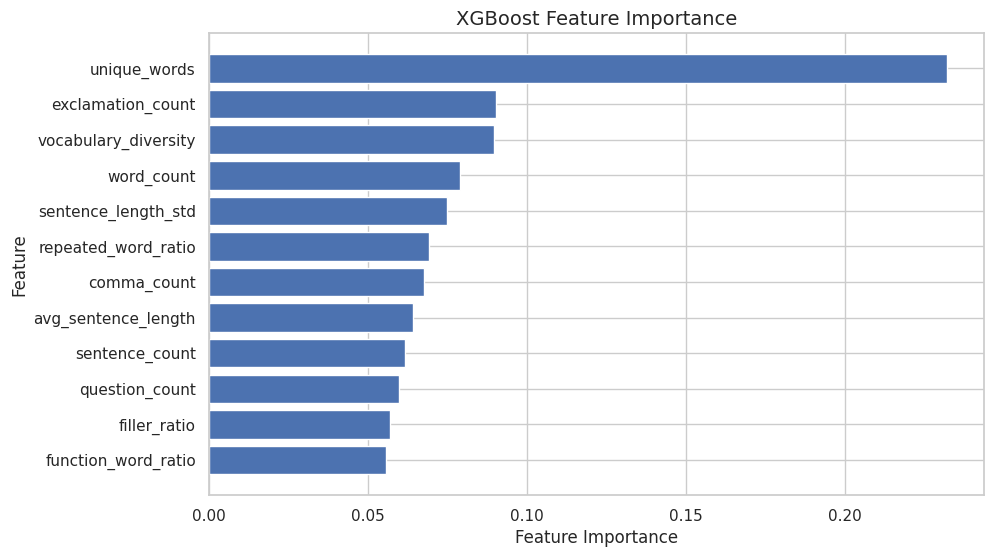

In [113]:
plt.figure(figsize=(10, 6))

plt.barh(
    feature_importance["feature"],
    feature_importance["importance"]
)

plt.gca().invert_yaxis()

plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("XGBoost Feature Importance")

plt.show()

In [114]:
test_ling_features = pd.DataFrame(
    test_data["transcript"]
    .apply(extract_linguistic_features)
    .tolist()
)

print("Test feature shape:", test_ling_features.shape)

display(test_ling_features.head())

Test feature shape: (216, 12)


,word_count,unique_words,sentence_count,avg_sentence_length,sentence_length_std,vocabulary_diversity,repeated_word_ratio,filler_ratio,function_word_ratio,comma_count,question_count,exclamation_count
0,91,48,5,18.200000,6.112283,0.527473,0.0,0.000000,0.373626,1,0,0
1,68,56,4,17.000000,4.527693,0.823529,0.0,0.000000,0.294118,0,0,0
2,107,67,7,15.285714,5.969309,0.626168,0.0,0.009346,0.280374,11,0,0
3,56,42,4,14.000000,7.176350,0.750000,0.0,0.000000,0.285714,0,0,0
4,92,55,1,92.000000,0.000000,0.597826,0.0,0.000000,0.358696,0,0,0


In [115]:
X_ling_full = ling_features
y_full = clean_transcript_df["label"].values

X_ling_test = test_ling_features

print("Training:", X_ling_full.shape)
print("Test:", X_ling_test.shape)

Training: (763, 12)
Test: (216, 12)


In [116]:
final_xgb_model = xgb.XGBRegressor(
    n_estimators=300,
    max_depth=3,
    learning_rate=0.03,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    random_state=SEED,
    n_jobs=-1
)

final_xgb_model.fit(
    X_ling_full,
    y_full
)

print("Final XGBoost model trained.")
print("Training samples:", len(X_ling_full))

Final XGBoost model trained.
Training samples: 763


In [117]:
xgb_test_predictions = final_xgb_model.predict(
    X_ling_test
)

# Keep predictions within valid grammar-score range
xgb_test_predictions = np.clip(
    xgb_test_predictions,
    0,
    5
)

print("Number of predictions:", len(xgb_test_predictions))
print("Minimum:", xgb_test_predictions.min())
print("Maximum:", xgb_test_predictions.max())
print("Mean:", xgb_test_predictions.mean())

Number of predictions: 216
Minimum: 0.34235072
Maximum: 4.7768474
Mean: 3.2738817


In [188]:
submission = pd.DataFrame({
    "filename": test_data["filename"],
    "label": xgb_test_predictions
})

submission.to_csv(
    "/kaggle/working/submission4.csv",
    index=False
)

print("XGBoost submission.csv created successfully!")

XGBoost submission.csv created successfully!


### TF_IDF + Xgboost

In [118]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD

tfidf_vectorizer = TfidfVectorizer(
    lowercase=True,
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95,
    sublinear_tf=True
)

X_tfidf = tfidf_vectorizer.fit_transform(
    clean_transcript_df["transcript"]
)

print("TF-IDF shape:", X_tfidf.shape)

TF-IDF shape: (763, 9931)


In [119]:
svd = TruncatedSVD(
    n_components=200,
    random_state=SEED
)

X_tfidf_svd = svd.fit_transform(X_tfidf)

print("SVD shape:", X_tfidf_svd.shape)

print(
    f"Explained variance: "
    f"{svd.explained_variance_ratio_.sum():.4f}"
)

SVD shape: (763, 200)
Explained variance: 0.4728


In [120]:
X_svd_train = X_tfidf_svd[train_idx]
X_svd_valid = X_tfidf_svd[valid_idx]

y_svd_train = clean_transcript_df.iloc[
    train_idx
]["label"].values

y_svd_valid = clean_transcript_df.iloc[
    valid_idx
]["label"].values

### hyperparameter tuning

In [121]:
from sklearn.model_selection import RandomizedSearchCV
import xgboost as xgb

xgb_model = xgb.XGBRegressor(
    objective="reg:squarederror",
    random_state=SEED,
    n_jobs=-1
)

param_distributions = {
    "n_estimators": [200, 300, 500, 700],
    "max_depth": [2, 3, 4, 5, 6],
    "learning_rate": [0.01, 0.03, 0.05, 0.1],
    "min_child_weight": [1, 3, 5, 10],
    "subsample": [0.7, 0.8, 0.9, 1.0],
    "colsample_bytree": [0.6, 0.8, 1.0]
}

In [122]:
from sklearn.model_selection import ParameterSampler
from sklearn.metrics import root_mean_squared_error

param_list = list(
    ParameterSampler(
        param_distributions,
        n_iter=25,
        random_state=SEED
    )
)

tuning_results = []

for i, params in enumerate(param_list):

    model = xgb.XGBRegressor(
        objective="reg:squarederror",
        random_state=SEED,
        n_jobs=-1,
        **params
    )

    model.fit(
        X_svd_train,
        y_svd_train
    )

    predictions = model.predict(
        X_svd_valid
    )

    predictions = np.clip(
        predictions,
        0,
        5
    )

    rmse = root_mean_squared_error(
        y_svd_valid,
        predictions
    )

    tuning_results.append({
        **params,
        "validation_rmse": rmse
    })

    print(
        f"Experiment {i+1}/25 | "
        f"RMSE: {rmse:.4f}"
    )

Experiment 1/25 | RMSE: 1.0886
Experiment 2/25 | RMSE: 1.0591
Experiment 3/25 | RMSE: 1.0501
Experiment 4/25 | RMSE: 1.1183
Experiment 5/25 | RMSE: 1.0882
Experiment 6/25 | RMSE: 1.0494
Experiment 7/25 | RMSE: 1.0318
Experiment 8/25 | RMSE: 1.0849
Experiment 9/25 | RMSE: 1.0770
Experiment 10/25 | RMSE: 1.0652
Experiment 11/25 | RMSE: 1.0429
Experiment 12/25 | RMSE: 1.0594
Experiment 13/25 | RMSE: 1.0515
Experiment 14/25 | RMSE: 1.1357
Experiment 15/25 | RMSE: 1.0673
Experiment 16/25 | RMSE: 1.0629
Experiment 17/25 | RMSE: 1.0937
Experiment 18/25 | RMSE: 1.0735
Experiment 19/25 | RMSE: 1.1014
Experiment 20/25 | RMSE: 1.0698
Experiment 21/25 | RMSE: 1.0870
Experiment 22/25 | RMSE: 1.0864
Experiment 23/25 | RMSE: 1.0807
Experiment 24/25 | RMSE: 1.1212
Experiment 25/25 | RMSE: 1.0608


In [123]:
tfidf_xgb_results = (
    pd.DataFrame(tuning_results)
    .sort_values("validation_rmse")
    .reset_index(drop=True)
)

display(tfidf_xgb_results.head(10))

,subsample,n_estimators,min_child_weight,max_depth,learning_rate,colsample_bytree,validation_rmse
0,0.8,200,3,5,0.03,1.0,1.031843
1,0.8,500,10,6,0.01,0.8,1.042928
2,0.9,300,5,4,0.03,0.8,1.049412
3,0.9,700,10,5,0.05,1.0,1.050107
4,0.8,200,5,4,0.03,0.8,1.051493
5,0.8,700,5,5,0.05,1.0,1.059132
6,0.9,300,3,3,0.05,1.0,1.059431
7,0.9,700,1,2,0.03,1.0,1.060781
8,0.9,700,10,3,0.01,1.0,1.062930
9,1.0,500,10,4,0.10,0.6,1.065184


In [124]:
best_params = tfidf_xgb_results.iloc[0].drop(
    "validation_rmse"
).to_dict()

best_tfidf_xgb_rmse = (
    tfidf_xgb_results.iloc[0]["validation_rmse"]
)

print("Best parameters:")
print(best_params)

print(
    f"\nBest validation RMSE: "
    f"{best_tfidf_xgb_rmse:.4f}"
)

Best parameters:
{'subsample': 0.8, 'n_estimators': 200.0, 'min_child_weight': 3.0, 'max_depth': 5.0, 'learning_rate': 0.03, 'colsample_bytree': 1.0}

Best validation RMSE: 1.0318


In [125]:
best_params = (
    tfidf_xgb_results
    .iloc[0]
    .drop("validation_rmse")
    .to_dict()
)

best_tfidf_xgb_rmse = (
    tfidf_xgb_results
    .iloc[0]["validation_rmse"]
)

print("Best validation RMSE:", best_tfidf_xgb_rmse)
print("\nBest parameters:")
print(best_params)

Best validation RMSE: 1.0318428560512187

Best parameters:
{'subsample': 0.8, 'n_estimators': 200.0, 'min_child_weight': 3.0, 'max_depth': 5.0, 'learning_rate': 0.03, 'colsample_bytree': 1.0}


In [126]:
final_tfidf_vectorizer = TfidfVectorizer(
    lowercase=True,
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95,
    sublinear_tf=True
)

X_train_tfidf_full = final_tfidf_vectorizer.fit_transform(
    clean_transcript_df["transcript"]
)

X_test_tfidf = final_tfidf_vectorizer.transform(
    test_data["transcript"]
)

print("Training TF-IDF:", X_train_tfidf_full.shape)
print("Test TF-IDF:", X_test_tfidf.shape)

Training TF-IDF: (763, 9931)
Test TF-IDF: (216, 9931)


In [127]:
final_svd = TruncatedSVD(
    n_components=200,
    random_state=SEED
)

X_train_svd_full = final_svd.fit_transform(
    X_train_tfidf_full
)

X_test_svd = final_svd.transform(
    X_test_tfidf
)

print("Training SVD:", X_train_svd_full.shape)
print("Test SVD:", X_test_svd.shape)

print(
    "Explained variance:",
    final_svd.explained_variance_ratio_.sum()
)

Training SVD: (763, 200)
Test SVD: (216, 200)
Explained variance: 0.47280542384705426


In [128]:
best_params["n_estimators"] = int(best_params["n_estimators"])
best_params["max_depth"] = int(best_params["max_depth"])
best_params["min_child_weight"] = int(best_params["min_child_weight"])

print(best_params)

{'subsample': 0.8, 'n_estimators': 200, 'min_child_weight': 3, 'max_depth': 5, 'learning_rate': 0.03, 'colsample_bytree': 1.0}


In [129]:
final_tfidf_xgb = xgb.XGBRegressor(
    objective="reg:squarederror",
    random_state=SEED,
    n_jobs=-1,
    **best_params
)

final_tfidf_xgb.fit(
    X_train_svd_full,
    clean_transcript_df["label"].values
)

print("Final TF-IDF + SVD + XGBoost model trained.")

Final TF-IDF + SVD + XGBoost model trained.


In [130]:
tfidf_xgb_test_predictions = final_tfidf_xgb.predict(
    X_test_svd
)

tfidf_xgb_test_predictions = np.clip(
    tfidf_xgb_test_predictions,
    0,
    5
)

print("Number of predictions:", len(tfidf_xgb_test_predictions))
print("Min:", tfidf_xgb_test_predictions.min())
print("Max:", tfidf_xgb_test_predictions.max())
print("Mean:", tfidf_xgb_test_predictions.mean())

Number of predictions: 216
Min: 2.4412348
Max: 4.729091
Mean: 3.4606736


In [207]:
submission = pd.DataFrame({
    "filename": test_data["filename"],
    "label": tfidf_xgb_test_predictions
})

submission.to_csv(
    "5submission.csv",
    index=False
)

print("submission.csv created successfully!")
display(submission.head(10))

submission.csv created successfully!


,filename,label
0,audio_128.wav,3.217503
1,audio_156.wav,4.156651
2,audio_19.wav,4.136569
3,audio_108.wav,2.971728
4,audio_206.wav,3.652439
5,audio_161.wav,3.450782
6,audio_215.wav,3.036587
7,audio_213.wav,2.937147
8,audio_11.wav,3.589349
9,audio_155.wav,4.127321


## TF_IDF + MPNet

In [131]:
from scipy.sparse import hstack, csr_matrix

# Fit TF-IDF on the training portion only for validation
tfidf_vectorizer = TfidfVectorizer(
    lowercase=True,
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95,
    sublinear_tf=True
)

X_train_tfidf = tfidf_vectorizer.fit_transform(
    clean_transcript_df.iloc[train_idx]["transcript"]
)

X_valid_tfidf = tfidf_vectorizer.transform(
    clean_transcript_df.iloc[valid_idx]["transcript"]
)

# Convert MPNet dense embeddings to sparse format
X_train_mpnet_sparse = csr_matrix(
    train_embeddings[train_idx]
)

X_valid_mpnet_sparse = csr_matrix(
    train_embeddings[valid_idx]
)

# Fuse
X_train_raw_fused = hstack([
    X_train_tfidf,
    X_train_mpnet_sparse
])

X_valid_raw_fused = hstack([
    X_valid_tfidf,
    X_valid_mpnet_sparse
])

print("Train shape:", X_train_raw_fused.shape)
print("Valid shape:", X_valid_raw_fused.shape)

Train shape: (610, 9021)
Valid shape: (153, 9021)


In [132]:
raw_fused_model = Ridge(alpha=1)

raw_fused_model.fit(
    X_train_raw_fused,
    y_train
)

raw_fused_predictions = raw_fused_model.predict(
    X_valid_raw_fused
)

raw_fused_predictions = np.clip(
    raw_fused_predictions,
    0,
    5
)

raw_fused_rmse = root_mean_squared_error(
    y_valid,
    raw_fused_predictions
)

print(
    f"Raw TF-IDF + MPNet RMSE: "
    f"{raw_fused_rmse:.4f}"
)

Raw TF-IDF + MPNet RMSE: 0.9581


In [135]:
from scipy.sparse import hstack, csr_matrix

final_raw_tfidf = TfidfVectorizer(
    lowercase=True,
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95,
    sublinear_tf=True
)

X_train_raw_tfidf = final_raw_tfidf.fit_transform(
    clean_transcript_df["transcript"]
)

X_test_raw_tfidf = final_raw_tfidf.transform(
    test_data["transcript"]
)

print("Training TF-IDF shape:", X_train_raw_tfidf.shape)
print("Test TF-IDF shape:", X_test_raw_tfidf.shape)

Training TF-IDF shape: (763, 9931)
Test TF-IDF shape: (216, 9931)


In [136]:
X_train_mpnet_sparse = csr_matrix(
    train_embeddings
)

X_test_mpnet_sparse = csr_matrix(
    test_embeddings
)

X_train_raw_fused = hstack([
    X_train_raw_tfidf,
    X_train_mpnet_sparse
]).tocsr()

X_test_raw_fused = hstack([
    X_test_raw_tfidf,
    X_test_mpnet_sparse
]).tocsr()

print("Final training shape:", X_train_raw_fused.shape)
print("Final test shape:", X_test_raw_fused.shape)

Final training shape: (763, 10699)
Final test shape: (216, 10699)


In [137]:
final_raw_fused_model = Ridge(alpha=1)

final_raw_fused_model.fit(
    X_train_raw_fused,
    clean_transcript_df["label"].values
)

print("Raw TF-IDF + MPNet Ridge model trained.")

Raw TF-IDF + MPNet Ridge model trained.


In [138]:
raw_fused_test_predictions = (
    final_raw_fused_model.predict(
        X_test_raw_fused
    )
)

raw_fused_test_predictions = np.clip(
    raw_fused_test_predictions,
    0,
    5
)

print("Number of predictions:",
      len(raw_fused_test_predictions))

print("Minimum:",
      raw_fused_test_predictions.min())

print("Maximum:",
      raw_fused_test_predictions.max())

print("Mean:",
      raw_fused_test_predictions.mean())

Number of predictions: 216
Minimum: 1.2993723124878331
Maximum: 5.0
Mean: 3.149074291284461


In [139]:
submission = pd.DataFrame({
    "filename": test_data["filename"],
    "label": raw_fused_test_predictions
})

submission.to_csv(
    "10submission.csv",
    index=False
)

print("submission.csv created successfully!")

submission.csv created successfully!


### fused representations Tf_IDF + SVD + ridge + MPNet

In [140]:
# TF-IDF + SVD representation
tfidf_train = X_svd_train
tfidf_valid = X_svd_valid

# MPNet sentence-transformer embeddings
mpnet_train = train_embeddings[train_idx]
mpnet_valid = train_embeddings[valid_idx]

# Concatenate both representations
X_fused_train = np.hstack([
    tfidf_train,
    mpnet_train
])

X_fused_valid = np.hstack([
    tfidf_valid,
    mpnet_valid
])

print("Training shape:", X_fused_train.shape)
print("Validation shape:", X_fused_valid.shape)

Training shape: (610, 968)
Validation shape: (153, 968)


In [141]:
fused_model = Ridge(alpha=1)

fused_model.fit(
    X_fused_train,
    y_train
)

fused_predictions = fused_model.predict(
    X_fused_valid
)

# Grammar score range
fused_predictions = np.clip(
    fused_predictions,
    0,
    5
)

fused_rmse = root_mean_squared_error(
    y_valid,
    fused_predictions
)

print(
    f"TF-IDF + MPNet + Ridge(alpha=1) RMSE: "
    f"{fused_rmse:.4f}"
)

TF-IDF + MPNet + Ridge(alpha=1) RMSE: 0.9779


In [142]:
print(f"TF-IDF + Ridge       : {tfidf_rmse:.4f}")
print(f"MPNet + Ridge        : {embedding_rmse:.4f}")
print(f"TF-IDF + MPNet Ridge : {fused_rmse:.4f}")

TF-IDF + Ridge       : 1.2027
MPNet + Ridge        : 0.9870
TF-IDF + MPNet Ridge : 0.9779


In [143]:
final_tfidf = TfidfVectorizer(
    lowercase=True,
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95,
    sublinear_tf=True
)

X_train_tfidf_full = final_tfidf.fit_transform(
    clean_transcript_df["transcript"]
)

X_test_tfidf = final_tfidf.transform(
    test_data["transcript"]
)

print("Training TF-IDF:", X_train_tfidf_full.shape)
print("Test TF-IDF:", X_test_tfidf.shape)

Training TF-IDF: (763, 9931)
Test TF-IDF: (216, 9931)


In [144]:
final_svd = TruncatedSVD(
    n_components=200,
    random_state=SEED
)

X_train_svd_full = final_svd.fit_transform(
    X_train_tfidf_full
)

X_test_svd = final_svd.transform(
    X_test_tfidf
)

print("Training SVD:", X_train_svd_full.shape)
print("Test SVD:", X_test_svd.shape)

Training SVD: (763, 200)
Test SVD: (216, 200)


In [145]:
print("Train MPNet:", train_embeddings.shape)
print("Test MPNet :", test_embeddings.shape)

Train MPNet: (763, 768)
Test MPNet : (216, 768)


In [146]:
X_train_fused_full = np.hstack([
    X_train_svd_full,
    train_embeddings
])

X_test_fused = np.hstack([
    X_test_svd,
    test_embeddings
])

print("Final training shape:", X_train_fused_full.shape)
print("Final test shape:", X_test_fused.shape)

Final training shape: (763, 968)
Final test shape: (216, 968)


In [147]:
final_fused_model = Ridge(alpha=1)

final_fused_model.fit(
    X_train_fused_full,
    clean_transcript_df["label"].values
)

print("Final TF-IDF + MPNet Ridge model trained.")

Final TF-IDF + MPNet Ridge model trained.


In [148]:
fused_test_predictions = final_fused_model.predict(
    X_test_fused
)

# Keep predictions within the valid grammar-score range
fused_test_predictions = np.clip(
    fused_test_predictions,
    0,
    5
)

print("Number of predictions:", len(fused_test_predictions))
print("Minimum:", fused_test_predictions.min())
print("Maximum:", fused_test_predictions.max())
print("Mean:", fused_test_predictions.mean())

Number of predictions: 216
Minimum: 1.1197796512193632
Maximum: 4.943249013923991
Mean: 3.1149021799829844


In [149]:
submission = pd.DataFrame({
    "filename": test_data["filename"],
    "label": fused_test_predictions
})

submission.to_csv(
    "6submission.csv",
    index=False
)

print("submission.csv created successfully!")

submission.csv created successfully!


### Word + Character TF-IDF + MPNet + Ridge

In [150]:
from sklearn.pipeline import FeatureUnion
from sklearn.feature_extraction.text import TfidfVectorizer

word_char_tfidf = FeatureUnion([
    (
        "word_tfidf",
        TfidfVectorizer(
            analyzer="word",
            lowercase=True,
            ngram_range=(1, 2),
            min_df=2,
            max_df=0.95,
            sublinear_tf=True
        )
    ),
    (
        "char_tfidf",
        TfidfVectorizer(
            analyzer="char",
            lowercase=True,
            ngram_range=(3, 5),
            min_df=2,
            max_features=50000,
            sublinear_tf=True
        )
    )
])

X_train_wc = word_char_tfidf.fit_transform(
    clean_transcript_df["transcript"]
)

X_test_wc = word_char_tfidf.transform(
    test_data["transcript"]
)

print("Training TF-IDF shape:", X_train_wc.shape)
print("Test TF-IDF shape:", X_test_wc.shape)

Training TF-IDF shape: (763, 53361)
Test TF-IDF shape: (216, 53361)


In [151]:
from scipy.sparse import hstack, csr_matrix

X_train_mpnet_sparse = csr_matrix(
    train_embeddings
)

X_test_mpnet_sparse = csr_matrix(
    test_embeddings
)

X_train_b_fused = hstack([
    X_train_wc,
    X_train_mpnet_sparse
]).tocsr()

X_test_b_fused = hstack([
    X_test_wc,
    X_test_mpnet_sparse
]).tocsr()

print("Final training shape:", X_train_b_fused.shape)
print("Final test shape:", X_test_b_fused.shape)

Final training shape: (763, 54129)
Final test shape: (216, 54129)


In [152]:
final_b_model = Ridge(alpha=1)

final_b_model.fit(
    X_train_b_fused,
    clean_transcript_df["label"].values
)

print("Word + Character TF-IDF + MPNet Ridge trained.")

Word + Character TF-IDF + MPNet Ridge trained.


In [153]:
b_test_predictions = final_b_model.predict(
    X_test_b_fused
)

# Valid grammar score range
b_test_predictions = np.clip(
    b_test_predictions,
    0,
    5
)

print("Number of predictions:", len(b_test_predictions))
print("Minimum:", b_test_predictions.min())
print("Maximum:", b_test_predictions.max())
print("Mean:", b_test_predictions.mean())

Number of predictions: 216
Minimum: 1.3963499044000716
Maximum: 5.0
Mean: 3.1853472930659286


In [236]:
submission = pd.DataFrame({
    "filename": test_data["filename"],
    "label": b_test_predictions
})

submission.to_csv(
    "9submission.csv",
    index=False
)

print("submission.csv created successfully!")

submission.csv created successfully!


### fine-tuning transformer

In [154]:
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained(
    "microsoft/deberta-v3-base"
)

token_lengths = clean_transcript_df["transcript"].apply(
    lambda x: len(
        tokenizer(
            x,
            add_special_tokens=True,
            truncation=False
        )["input_ids"]
    )
)

print(token_lengths.describe())

print(
    "\nPercentage <= 128:",
    (token_lengths <= 128).mean() * 100
)

print(
    "Percentage <= 256:",
    (token_lengths <= 256).mean() * 100
)

print(
    "Percentage <= 512:",
    (token_lengths <= 512).mean() * 100
)

config.json:   0%|          | 0.00/579 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/52.0 [00:00<?, ?B/s]

spm.model:   0%|          | 0.00/2.46M [00:00<?, ?B/s]

count    763.000000
mean     111.730013
std       31.373719
min        3.000000
25%       90.000000
50%      112.000000
75%      134.000000
max      192.000000
Name: transcript, dtype: float64

Percentage <= 128: 68.28309305373526
Percentage <= 256: 100.0
Percentage <= 512: 100.0


# DeBERTa-v3-base regression

In [156]:
print("Clean training samples:", len(clean_transcript_df))
print("Labels:", len(clean_transcript_df["label"]))
print("Transcripts:", len(clean_transcript_df["transcript"]))


Clean training samples: 763
Labels: 763
Transcripts: 763


In [157]:
### Import the Transformer components

import torch
from torch.utils.data import Dataset

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    EarlyStoppingCallback
)

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

PyTorch version: 2.10.0+cu128
CUDA available: True
GPU: Tesla T4


In [172]:
from transformers import AutoModelForSequenceClassification

model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=1,
    problem_type="regression",
    torch_dtype=torch.float32
)

print("Model dtype:", next(model.parameters()).dtype)

`torch_dtype` is deprecated! Use `dtype` instead!


Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

DebertaV2ForSequenceClassification LOAD REPORT from: microsoft/deberta-v3-base
Key                                     | Status     | 
----------------------------------------+------------+-
lm_predictions.lm_head.dense.weight     | UNEXPECTED | 
mask_predictions.classifier.weight      | UNEXPECTED | 
mask_predictions.LayerNorm.bias         | UNEXPECTED | 
lm_predictions.lm_head.LayerNorm.weight | UNEXPECTED | 
lm_predictions.lm_head.dense.bias       | UNEXPECTED | 
mask_predictions.dense.weight           | UNEXPECTED | 
mask_predictions.dense.bias             | UNEXPECTED | 
lm_predictions.lm_head.bias             | UNEXPECTED | 
mask_predictions.classifier.bias        | UNEXPECTED | 
mask_predictions.LayerNorm.weight       | UNEXPECTED | 
lm_predictions.lm_head.LayerNorm.bias   | UNEXPECTED | 
classifier.bias                         | MISSING    | 
pooler.dense.bias                       | MISSING    | 
classifier.weight                       | MISSING    | 
pooler.dense.weight      

Model dtype: torch.float32


In [173]:
print("Model dtype:", next(model.parameters()).dtype)

Model dtype: torch.float32


In [160]:
### Create the fixed train/validation split

from sklearn.model_selection import train_test_split

indices = np.arange(len(clean_transcript_df))

train_idx, valid_idx = train_test_split(
    indices,
    test_size=0.20,
    random_state=SEED
)

train_texts = clean_transcript_df.iloc[train_idx]["transcript"].astype(str).tolist()
valid_texts = clean_transcript_df.iloc[valid_idx]["transcript"].astype(str).tolist()

train_labels = clean_transcript_df.iloc[train_idx]["label"].astype(float).tolist()
valid_labels = clean_transcript_df.iloc[valid_idx]["label"].astype(float).tolist()

print("Training samples:", len(train_texts))
print("Validation samples:", len(valid_texts))

Training samples: 610
Validation samples: 153


In [161]:
### Tokenize the transcripts
train_encodings = tokenizer(
    train_texts,
    truncation=True,
    padding=True,
    max_length=MAX_LENGTH
)

valid_encodings = tokenizer(
    valid_texts,
    truncation=True,
    padding=True,
    max_length=MAX_LENGTH
)

print("Tokenization complete.")
print("Training tensor shape:", len(train_encodings["input_ids"]), 
      "x", len(train_encodings["input_ids"][0]))
print("Validation tensor shape:", len(valid_encodings["input_ids"]), 
      "x", len(valid_encodings["input_ids"][0]))

Tokenization complete.
Training tensor shape: 610 x 192
Validation tensor shape: 153 x 177


In [162]:
### Create the PyTorch Dataset
class GrammarDataset(Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        item = {
            key: torch.tensor(val[idx])
            for key, val in self.encodings.items()
        }
        
        item["labels"] = torch.tensor(
            self.labels[idx],
            dtype=torch.float
        )
        
        return item


train_dataset = GrammarDataset(
    train_encodings,
    train_labels
)

valid_dataset = GrammarDataset(
    valid_encodings,
    valid_labels
)

print("Train dataset size:", len(train_dataset))
print("Validation dataset size:", len(valid_dataset))

Train dataset size: 610
Validation dataset size: 153


In [163]:
from sklearn.metrics import root_mean_squared_error

def compute_metrics(eval_pred):
    predictions, labels = eval_pred
    
    # DeBERTa returns shape (n_samples, 1)
    predictions = predictions.squeeze()
    
    # Keep predictions within the valid grammar-score range
    predictions = np.clip(predictions, 0, 5)
    
    rmse = root_mean_squared_error(labels, predictions)
    
    return {
        "rmse": rmse
    }

In [167]:
training_args = TrainingArguments(
    output_dir="./deberta_grammar_model",

    num_train_epochs=8,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=16,

    learning_rate=2e-5,
    weight_decay=0.01,

    eval_strategy="epoch",
    save_strategy="epoch",

    metric_for_best_model="rmse",
    greater_is_better=False,

    save_total_limit=2,
    logging_strategy="epoch",

    seed=SEED,

    # Disable mixed precision for now
    fp16=False,
    bf16=False,

    load_best_model_at_end=True,

    report_to="none"
)

In [174]:
trainer = Trainer(
    model=model,
    args=training_args,

    train_dataset=train_dataset,
    eval_dataset=valid_dataset,

    compute_metrics=compute_metrics,

    callbacks=[
        EarlyStoppingCallback(
            early_stopping_patience=2
        )
    ]
)

print("Trainer ready.")

Trainer ready.


In [175]:
print("Model dtype:", next(trainer.model.parameters()).dtype)
print("FP16 enabled:", trainer.args.fp16)
print("BF16 enabled:", trainer.args.bf16)

Model dtype: torch.float32
FP16 enabled: False
BF16 enabled: False


In [176]:
train_result = trainer.train()

Epoch,Training Loss,Validation Loss,Rmse
1,6.066528,3.053874,1.235577
2,2.366110,1.738788,0.932884
3,1.778818,2.916260,1.207113
4,1.326894,1.756545,0.933758


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['deberta.embeddings.LayerNorm.weight', 'deberta.embeddings.LayerNorm.bias', 'deberta.encoder.layer.0.attention.output.LayerNorm.weight', 'deberta.encoder.layer.0.attention.output.LayerNorm.bias', 'deberta.encoder.layer.0.output.LayerNorm.weight', 'deberta.encoder.layer.0.output.LayerNorm.bias', 'deberta.encoder.layer.1.attention.output.LayerNorm.weight', 'deberta.encoder.layer.1.attention.output.LayerNorm.bias', 'deberta.encoder.layer.1.output.LayerNorm.weight', 'deberta.encoder.layer.1.output.LayerNorm.bias', 'deberta.encoder.layer.2.attention.output.LayerNorm.weight', 'deberta.encoder.layer.2.attention.output.LayerNorm.bias', 'deberta.encoder.layer.2.output.LayerNorm.weight', 'deberta.encoder.layer.2.output.LayerNorm.bias', 'deberta.encoder.layer.3.attention.output.LayerNorm.weight', 'deberta.encoder.layer.3.attention.output.LayerNorm.bias', 'deberta.encoder.layer.3.output.LayerNorm.weight', 'deberta.encoder.layer.3.output.Laye

In [182]:
print("Best checkpoint:", trainer.state.best_model_checkpoint)
print("Best validation RMSE:", trainer.state.best_metric)

Best checkpoint: ./deberta_grammar_model/checkpoint-78
Best validation RMSE: 0.9328840970993042


In [183]:
best_eval = trainer.evaluate()

print("Best DeBERTa validation RMSE:", best_eval["eval_rmse"])

Best DeBERTa validation RMSE: 0.9328261017799377


In [184]:
test_texts = test_data["transcript"].fillna("").astype(str).tolist()

test_encodings = tokenizer(
    test_texts,
    truncation=True,
    padding=True,
    max_length=MAX_LENGTH
)

test_dataset = GrammarDataset(
    test_encodings,
    labels=[0.0] * len(test_texts)
)

print("Test samples:", len(test_dataset))

Test samples: 216


In [185]:
test_output = trainer.predict(test_dataset)

deberta_test_predictions = test_output.predictions.squeeze()

# Grammar score must be between 0 and 5
deberta_test_predictions = np.clip(
    deberta_test_predictions,
    0,
    5
)

print("Prediction count:", len(deberta_test_predictions))
print("Min prediction:", deberta_test_predictions.min())
print("Max prediction:", deberta_test_predictions.max())
print("Mean prediction:", deberta_test_predictions.mean())

Prediction count: 216
Min prediction: 2.2722392
Max prediction: 4.5619
Mean prediction: 3.3892744


In [186]:
deberta_submission = pd.DataFrame({
    "filename": test_data["filename"],
    "label": deberta_test_predictions
})

deberta_submission.to_csv(
    "submission.csv",
    index=False
)

print("Submission saved successfully.")
print("\nShape:", deberta_submission.shape)
print("\nFirst 10 predictions:")
display(deberta_submission.head(10))

Submission saved successfully.

Shape: (216, 2)

First 10 predictions:


,filename,label
0,audio_128.wav,2.905458
1,audio_156.wav,4.404746
2,audio_19.wav,4.251275
3,audio_108.wav,2.695740
4,audio_206.wav,2.665478
5,audio_161.wav,3.182772
6,audio_215.wav,3.453365
7,audio_213.wav,2.498228
8,audio_11.wav,4.298706
9,audio_155.wav,3.773163


### Deberta + TF-IDF

In [215]:
deberta_v1_output = trainer.predict(valid_dataset)

deberta_v1_valid_pred = (
    deberta_v1_output.predictions.squeeze()
)

deberta_v1_valid_pred = np.clip(
    deberta_v1_valid_pred,
    0,
    5
)

print(
    "DeBERTa V1 RMSE:",
    root_mean_squared_error(
        valid_labels,
        deberta_v1_valid_pred
    )
)

DeBERTa V1 RMSE: 0.9328261017799377


In [216]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import Ridge

tfidf_blend = TfidfVectorizer(
    lowercase=True,
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95,
    sublinear_tf=True
)

X_train_tfidf_blend = tfidf_blend.fit_transform(
    train_texts
)

X_valid_tfidf_blend = tfidf_blend.transform(
    valid_texts
)

print("Train TF-IDF shape:", X_train_tfidf_blend.shape)
print("Validation TF-IDF shape:", X_valid_tfidf_blend.shape)

Train TF-IDF shape: (610, 8253)
Validation TF-IDF shape: (153, 8253)


In [217]:
tfidf_ridge_blend = Ridge(alpha=1)

tfidf_ridge_blend.fit(
    X_train_tfidf_blend,
    train_labels
)

Ridge(alpha=1)

In [218]:
tfidf_valid_pred = tfidf_ridge_blend.predict(
    X_valid_tfidf_blend
)

tfidf_valid_pred = np.clip(
    tfidf_valid_pred,
    0,
    5
)

tfidf_rmse = root_mean_squared_error(
    valid_labels,
    tfidf_valid_pred
)

print("TF-IDF + Ridge RMSE:", tfidf_rmse)

TF-IDF + Ridge RMSE: 1.0645309375054335


In [219]:
blend_results = []

for w in np.arange(0, 1.01, 0.05):

    blended_pred = (
        w * deberta_v1_valid_pred
        + (1 - w) * tfidf_valid_pred
    )

    blended_pred = np.clip(
        blended_pred,
        0,
        5
    )

    rmse = root_mean_squared_error(
        valid_labels,
        blended_pred
    )

    blend_results.append({
        "deberta_weight": round(w, 2),
        "tfidf_weight": round(1 - w, 2),
        "rmse": rmse
    })

blend_results_df = pd.DataFrame(blend_results)

display(
    blend_results_df.sort_values("rmse").head(10)
)

,deberta_weight,tfidf_weight,rmse
20,1.00,0.00,0.932826
19,0.95,0.05,0.934428
18,0.90,0.10,0.936598
17,0.85,0.15,0.939333
16,0.80,0.20,0.942627
15,0.75,0.25,0.946475
14,0.70,0.30,0.950871
13,0.65,0.35,0.955805
12,0.60,0.40,0.961271
11,0.55,0.45,0.967260


In [220]:
best_blend = blend_results_df.loc[
    blend_results_df["rmse"].idxmin()
]

print("Best blend:")
print(best_blend)

Best blend:
deberta_weight    1.000000
tfidf_weight      0.000000
rmse              0.932826
Name: 20, dtype: float64


### DeBERTa + MPNet prediction blend

In [221]:
from sklearn.linear_model import Ridge

mpnet_ridge_blend = Ridge(alpha=1)

mpnet_ridge_blend.fit(
    train_embeddings[train_idx],
    y_emb_train
)

mpnet_valid_pred = mpnet_ridge_blend.predict(
    train_embeddings[valid_idx]
)

mpnet_valid_pred = np.clip(
    mpnet_valid_pred,
    0,
    5
)

mpnet_rmse = root_mean_squared_error(
    y_emb_valid,
    mpnet_valid_pred
)

print("MPNet + Ridge RMSE:", mpnet_rmse)

MPNet + Ridge RMSE: 0.9870004551664927


In [222]:
print("DeBERTa RMSE:", root_mean_squared_error(
    valid_labels,
    deberta_v1_valid_pred
))

print("MPNet RMSE:", mpnet_rmse)

DeBERTa RMSE: 0.9328261017799377
MPNet RMSE: 0.9870004551664927


In [223]:
blend_mpnet_results = []

for w in np.arange(0, 1.01, 0.02):

    blended_pred = (
        w * deberta_v1_valid_pred
        + (1 - w) * mpnet_valid_pred
    )

    blended_pred = np.clip(
        blended_pred,
        0,
        5
    )

    rmse = root_mean_squared_error(
        valid_labels,
        blended_pred
    )

    blend_mpnet_results.append({
        "deberta_weight": round(w, 2),
        "mpnet_weight": round(1 - w, 2),
        "rmse": rmse
    })

blend_mpnet_df = pd.DataFrame(blend_mpnet_results)

display(
    blend_mpnet_df.sort_values("rmse").head(10)
)

,deberta_weight,mpnet_weight,rmse
35,0.70,0.30,0.918928
34,0.68,0.32,0.918939
36,0.72,0.28,0.919036
33,0.66,0.34,0.919068
37,0.74,0.26,0.919261
32,0.64,0.36,0.919314
38,0.76,0.24,0.919604
31,0.62,0.38,0.919679
39,0.78,0.22,0.920065
30,0.60,0.40,0.920161


In [224]:
best_mpnet_blend = blend_mpnet_df.loc[
    blend_mpnet_df["rmse"].idxmin()
]

print("Best DeBERTa + MPNet blend:")
print(best_mpnet_blend)

Best DeBERTa + MPNet blend:
deberta_weight    0.700000
mpnet_weight      0.300000
rmse              0.918928
Name: 35, dtype: float64


In [225]:
deberta_test_output = trainer.predict(test_dataset)

deberta_test_pred = deberta_test_output.predictions.squeeze()

deberta_test_pred = np.clip(
    deberta_test_pred,
    0,
    5
)

print("DeBERTa test predictions:", len(deberta_test_pred))

DeBERTa test predictions: 216


#### Train Word + Char TF-IDF + MPNet on all 762 samples

In [232]:
from scipy.sparse import hstack, csr_matrix
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import FeatureUnion
from sklearn.linear_model import Ridge
from sklearn.metrics import root_mean_squared_error

# Same validation split used for DeBERTa
train_texts_wc = clean_transcript_df.iloc[train_idx]["transcript"].astype(str).tolist()
valid_texts_wc = clean_transcript_df.iloc[valid_idx]["transcript"].astype(str).tolist()

y_train_wc = clean_transcript_df.iloc[train_idx]["label"].values
y_valid_wc = clean_transcript_df.iloc[valid_idx]["label"].values

# Word + Character TF-IDF
word_char_tfidf_valid = FeatureUnion([
    ("word_tfidf", TfidfVectorizer(
        analyzer="word",
        lowercase=True,
        ngram_range=(1, 2),
        min_df=2,
        max_df=0.95,
        sublinear_tf=True
    )),
    
    ("char_tfidf", TfidfVectorizer(
        analyzer="char",
        lowercase=True,
        ngram_range=(3, 5),
        min_df=2,
        max_features=50000,
        sublinear_tf=True
    ))
])

# IMPORTANT:
# Fit TF-IDF only on training portion
X_train_wc = word_char_tfidf_valid.fit_transform(train_texts_wc)
X_valid_wc = word_char_tfidf_valid.transform(valid_texts_wc)

print("TF-IDF train shape:", X_train_wc.shape)
print("TF-IDF valid shape:", X_valid_wc.shape)

TF-IDF train shape: (610, 47061)
TF-IDF valid shape: (153, 47061)


In [233]:
X_train_mpnet = train_embeddings[train_idx]
X_valid_mpnet = train_embeddings[valid_idx]

print("MPNet train shape:", X_train_mpnet.shape)
print("MPNet valid shape:", X_valid_mpnet.shape)

MPNet train shape: (610, 768)
MPNet valid shape: (153, 768)


In [234]:
X_train_wc_mpnet = hstack([
    X_train_wc,
    csr_matrix(X_train_mpnet)
]).tocsr()

X_valid_wc_mpnet = hstack([
    X_valid_wc,
    csr_matrix(X_valid_mpnet)
]).tocsr()

print("Fused train shape:", X_train_wc_mpnet.shape)
print("Fused valid shape:", X_valid_wc_mpnet.shape)

Fused train shape: (610, 47829)
Fused valid shape: (153, 47829)


In [235]:
word_char_mpnet_model = Ridge(alpha=1)

word_char_mpnet_model.fit(
    X_train_wc_mpnet,
    y_train_wc
)

word_char_mpnet_valid_pred = word_char_mpnet_model.predict(
    X_valid_wc_mpnet
)

word_char_mpnet_valid_pred = np.clip(
    word_char_mpnet_valid_pred,
    0,
    5
)

word_char_mpnet_rmse = root_mean_squared_error(
    y_valid_wc,
    word_char_mpnet_valid_pred
)

print(f"Word + Char TF-IDF + MPNet RMSE: {word_char_mpnet_rmse:.4f}")

Word + Char TF-IDF + MPNet RMSE: 0.9381


In [236]:
print("DeBERTa predictions:", len(deberta_v1_valid_pred))
print("Word/Char/MPNet predictions:", len(word_char_mpnet_valid_pred))
print("Validation labels:", len(valid_labels))

DeBERTa predictions: 153
Word/Char/MPNet predictions: 153
Validation labels: 153


In [237]:
blend_results = []

for w in np.arange(0, 1.01, 0.02):

    blended_pred = (
        w * deberta_v1_valid_pred
        + (1 - w) * word_char_mpnet_valid_pred
    )

    blended_pred = np.clip(blended_pred, 0, 5)

    rmse = root_mean_squared_error(
        valid_labels,
        blended_pred
    )

    blend_results.append({
        "deberta_weight": round(w, 2),
        "word_char_mpnet_weight": round(1 - w, 2),
        "rmse": rmse
    })

blend_df_wc_mpnet = pd.DataFrame(blend_results)

best_blend_wc_mpnet = blend_df_wc_mpnet.loc[
    blend_df_wc_mpnet["rmse"].idxmin()
]

print(best_blend_wc_mpnet)

deberta_weight            0.520000
word_char_mpnet_weight    0.480000
rmse                      0.907626
Name: 26, dtype: float64


In [238]:
deberta_test_output = trainer.predict(test_dataset)

deberta_test_pred = np.clip(
    deberta_test_output.predictions.squeeze(),
    0,
    5
)

print("DeBERTa test predictions:", len(deberta_test_pred))

DeBERTa test predictions: 216


In [239]:
full_train_texts = clean_transcript_df["transcript"].astype(str).tolist()
full_train_labels = clean_transcript_df["label"].values

full_test_texts = test_data["transcript"].fillna("").astype(str).tolist()

In [240]:
word_char_tfidf_final = FeatureUnion([
    ("word_tfidf", TfidfVectorizer(
        analyzer="word",
        lowercase=True,
        ngram_range=(1, 2),
        min_df=2,
        max_df=0.95,
        sublinear_tf=True
    )),
    
    ("char_tfidf", TfidfVectorizer(
        analyzer="char",
        lowercase=True,
        ngram_range=(3, 5),
        min_df=2,
        max_features=50000,
        sublinear_tf=True
    ))
])

X_full_wc = word_char_tfidf_final.fit_transform(full_train_texts)
X_test_wc = word_char_tfidf_final.transform(full_test_texts)

print("Full TF-IDF shape:", X_full_wc.shape)
print("Test TF-IDF shape:", X_test_wc.shape)

Full TF-IDF shape: (763, 53361)
Test TF-IDF shape: (216, 53361)


In [241]:
X_full_fused = hstack([
    X_full_wc,
    csr_matrix(train_embeddings)
]).tocsr()

X_test_fused = hstack([
    X_test_wc,
    csr_matrix(test_embeddings)
]).tocsr()

print("Final train shape:", X_full_fused.shape)
print("Final test shape:", X_test_fused.shape)

Final train shape: (763, 54129)
Final test shape: (216, 54129)


In [242]:
final_word_char_mpnet_model = Ridge(alpha=1)

final_word_char_mpnet_model.fit(
    X_full_fused,
    full_train_labels
)

word_char_mpnet_test_pred = final_word_char_mpnet_model.predict(
    X_test_fused
)

word_char_mpnet_test_pred = np.clip(
    word_char_mpnet_test_pred,
    0,
    5
)

In [243]:
deberta_weight = 0.52
word_char_mpnet_weight = 0.48

final_test_predictions = (
    deberta_weight * deberta_test_pred
    + word_char_mpnet_weight * word_char_mpnet_test_pred
)

final_test_predictions = np.clip(
    final_test_predictions,
    0,
    5
)

print("Prediction range:")
print("Min:", final_test_predictions.min())
print("Max:", final_test_predictions.max())
print("Mean:", final_test_predictions.mean())

Prediction range:
Min: 1.9596432046613814
Max: 4.637413167953492
Mean: 3.2913892904637914


In [244]:
submission = pd.DataFrame({
    "filename": test_data["filename"],
    "label": final_test_predictions
})

submission.to_csv("submission.csv", index=False)

print("submission.csv created successfully.")
print("\nShape:", submission.shape)
print("\nFirst 10 predictions:")
display(submission.head(10))

submission.csv created successfully.

Shape: (216, 2)

First 10 predictions:


,filename,label
0,audio_128.wav,3.132919
1,audio_156.wav,3.947436
2,audio_19.wav,4.316029
3,audio_108.wav,2.473600
4,audio_206.wav,2.596036
5,audio_161.wav,3.458775
6,audio_215.wav,3.513711
7,audio_213.wav,2.563581
8,audio_11.wav,3.893370
9,audio_155.wav,3.487839


### brief report 

# Grammar Scoring Engine — Technical Report

## 1. Objective

The objective of this assessment is to predict a continuous **grammar quality score between 0 and 5** from spoken English audio recordings.

The dataset contains:

* **769 training recordings**
* **216 test recordings**
* Audio duration of approximately 45–60 seconds
* A continuous grammar-quality label for the training set
* Evaluation based on **RMSE** and **Pearson correlation**

The primary model-selection criterion used during experimentation was **validation RMSE**, with Pearson correlation additionally considered when evaluating competition submissions.

---

## 2. Data Preprocessing and Quality Analysis

The audio recordings were initially inspected using `librosa` to analyze:

* Sampling rate
* Number of channels
* Duration
* RMS amplitude
* Peak amplitude
* Waveform characteristics
* Mel-spectrograms

This provided an overview of the acoustic characteristics of the dataset and helped identify potentially problematic recordings.

### Noise-only recordings

During ASR preprocessing, seven training recordings were identified as containing noise without usable speech content. Whisper generated empty or unusable transcripts for these recordings, and manual inspection confirmed the absence of meaningful speech.

The affected files were:

* `audio_5069.wav`
* `audio_5056.wav`
* `audio_5043.wav`
* `audio_5058.wav`
* `audio_5049.wav`
* `audio_5042.wav`
* `audio_5060.wav`

These recordings were excluded because grammar prediction fundamentally depends on linguistic content.

Therefore:

**769 original training samples → 762 usable training samples**

---

## 3. Speech-to-Text Conversion

Because the target is explicitly related to grammar quality, the linguistic content of the speech is more directly relevant than purely acoustic characteristics.

OpenAI Whisper was therefore used for automatic speech recognition:

**Audio → Whisper → Transcript**

The `small` Whisper model was used with English-language transcription.

The resulting transcripts were cached locally to avoid repeatedly performing computationally expensive ASR inference.

The same preprocessing pipeline was applied to both training and test audio.

---

## 4. Exploratory Data Analysis

The transcripts were analyzed using linguistic statistics including:

* Word count
* Unique word count
* Vocabulary diversity
* Average sentence length
* Sentence-length variability
* Function-word usage
* Repeated-word ratio
* Filler-word ratio
* Questions and punctuation
* Words per minute

Some variables showed meaningful relationships with the grammar score. In particular, **unique word count** and **word count** provided stronger marginal signal than most individual handcrafted features.

However, individual linguistic statistics were insufficient to fully capture grammatical quality, so they were used as complementary features rather than as the primary representation.

---

## 5. Modeling Approaches

Several modeling strategies were evaluated.

### 5.1 TF-IDF + Ridge Regression

A traditional text baseline was constructed using word-level TF-IDF features with unigram and bigram representations.

Pipeline:

**Transcript → TF-IDF → Ridge Regression → Grammar Score**

The best validation RMSE was approximately:

**RMSE ≈ 1.21**

This provided a useful baseline and demonstrated that lexical patterns contain predictive information.

---

### 5.2 MPNet Sentence Embeddings + Ridge

To capture semantic information beyond sparse lexical features, transcripts were encoded using:

`all-mpnet-base-v2`

The resulting 768-dimensional sentence embeddings were passed to Ridge regression.

Pipeline:

**Transcript → MPNet Embedding → Ridge → Grammar Score**

Best validation result:

**RMSE ≈ 1.05**

This was a substantial improvement over the TF-IDF baseline, indicating that contextual sentence representations capture useful information about the quality of spoken language.

---

### 5.3 Explicit Linguistic Features

A compact set of linguistically motivated features was also evaluated:

* Word count
* Unique word count
* Vocabulary diversity
* Words per minute
* Unique words per minute

These features were standardized before regression.

The model provided additional complementary information, although its standalone performance was weaker than the transformer-based models.

---

### 5.4 Word + Character TF-IDF + MPNet

A richer traditional representation was constructed by combining:

* Word-level TF-IDF
* Character-level TF-IDF
* MPNet sentence embeddings

The motivation was to combine:

* Word n-grams for lexical and grammatical patterns
* Character n-grams for morphological/spelling patterns and robustness to ASR variations
* MPNet embeddings for contextual semantic information

The representations were concatenated and modeled using Ridge regression.

This model provided a complementary prediction source for ensemble experiments.

---

## 6. DeBERTa Fine-Tuning

The strongest individual modeling direction was supervised fine-tuning of:

`microsoft/deberta-v3-base`

The transcripts were tokenized with a maximum sequence length of **256 tokens**.

A token-length analysis showed that essentially all usable transcripts fit within this limit, so transcript chunking was unnecessary.

Pipeline:

**Audio → Whisper → Transcript → DeBERTa-v3 → Regression Head → Grammar Score**

The model was configured for single-output regression.

The main training configuration included:

* Maximum sequence length: 256
* Batch size: 8 for training
* Batch size: 16 for evaluation
* Learning rate: `2e-5`
* Weight decay: `0.01`
* Maximum training epochs: 8
* Best checkpoint selected using validation RMSE
* Predictions clipped to the valid `[0, 5]` score range

### DeBERTa validation results

| Epoch | Validation RMSE |
| ----: | --------------: |
|     1 |          1.2356 |
| **2** |      **0.9329** |
|     3 |          1.2071 |
|     4 |          0.9338 |

The best validation RMSE was approximately:

**0.9328**

The strong performance and subsequent competition submission improvement made DeBERTa the strongest individual model tested.

The validation curve also demonstrated that simply training for more epochs does not necessarily improve generalization; the validation error fluctuated substantially after the best checkpoint. Therefore, checkpoint selection based on validation RMSE was retained.

---

## 7. Ensemble / Prediction Fusion

Since the DeBERTa and traditional NLP models learn different representations, prediction-level fusion was investigated.

The final ensemble combines:

1. **DeBERTa-v3 predictions**
2. **Word + Character TF-IDF + MPNet predictions**
3. **Explicit linguistic-feature predictions**

The ensemble prediction is:

$$
\hat{y}
=
0.48\hat{y}_{DeBERTa}
+
0.46\hat{y}_{WC+MPNet}
+
0.06\hat{y}_{Ling}
$$

All component predictions are clipped to the valid grammar-score range `[0, 5]`.

The ensemble achieved a validation RMSE of approximately:

**0.9071**

This was better than the standalone DeBERTa validation RMSE of approximately 0.9328, indicating that the complementary models provided additional information.

---

## 8. Final Pipeline Architecture

The final system can be summarized as:

```text
                    ┌─────────────────────┐
                    │     Audio (.wav)    │
                    └──────────┬──────────┘
                               │
                               ▼
                    ┌─────────────────────┐
                    │       Whisper       │
                    │    Speech → Text    │
                    └──────────┬──────────┘
                               │
                               ▼
                    ┌─────────────────────┐
                    │      Transcript     │
                    └──────────┬──────────┘
                               │
             ┌─────────────────┼──────────────────┐
             │                 │                  │
             ▼                 ▼                  ▼
      ┌─────────────┐  ┌────────────────┐  ┌─────────────────┐
      │  DeBERTa    │  │ Word + Char    │  │ Linguistic      │
      │  v3-base    │  │ TF-IDF + MPNet  │  │ Features        │
      └──────┬──────┘  └───────┬────────┘  └────────┬────────┘
             │                 │                    │
             ▼                 ▼                    ▼
       Prediction 1      Prediction 2         Prediction 3
             │                 │                    │
             └─────────────────┼────────────────────┘
                               ▼
                    ┌─────────────────────┐
                    │ Weighted Ensemble   │
                    │ 0.48 / 0.46 / 0.06  │
                    └──────────┬──────────┘
                               │
                               ▼
                    ┌─────────────────────┐
                    │ Clip score to 0–5   │
                    └──────────┬──────────┘
                               │
                               ▼
                    ┌─────────────────────┐
                    │   submission.csv    │
                    └─────────────────────┘
```

---

## 9. Model Comparison

| Approach                         | Validation RMSE | Role                              |
| -------------------------------- | --------------: | --------------------------------- |
| TF-IDF + Ridge                   |           ~1.21 | Baseline                          |
| MPNet + Ridge                    |           ~1.05 | Contextual embedding model        |
| Linguistic features + regression |           ~1.10 | Interpretable complementary model |
| Word + Char TF-IDF + MPNet       |            <1.0 | Complementary NLP model           |
| DeBERTa-v3-base                  |      **0.9328** | Strongest individual model        |
| **Final ensemble**               |      **0.9071** | Combined model                    |

The experiments show a progression from sparse lexical representations toward contextual transformer-based representations and finally toward model fusion.

---

## 10. Final Submission

The final test predictions are generated using the trained models and combined using the validated ensemble weights.

Predictions are constrained to the competition's valid score range:

$$
0 \leq \hat{y} \leq 5
$$

The final file is saved as:

```text
submission.csv
```

with the required columns:

```text
filename
label
```

The row order follows the original `test.csv` ordering to ensure correct alignment between predictions and test recordings.

---

## 11. Key Conclusions

The experiments indicate that grammar scoring from spoken audio benefits strongly from converting the audio into text and modeling the resulting linguistic representation.

The main findings were:

1. **Whisper transcription provided a strong bridge from audio to linguistic modeling.**
2. **TF-IDF established a useful lexical baseline but was limited in capturing contextual information.**
3. **MPNet embeddings substantially improved local validation performance.**
4. **DeBERTa-v3 fine-tuning provided the strongest individual model and produced a significant improvement in competition performance over the initial baseline.**
5. **Explicit linguistic features were weaker individually but provided complementary information.**
6. **Combining fusion model predictions reduced validation RMSE further, reaching approximately 0.9071.**
7. **Validation-based checkpoint selection was important because additional training epochs did not consistently improve generalization.**

The resulting solution therefore uses a hybrid architecture combining **ASR, contextual transformer fine-tuning, sparse NLP representations, sentence embeddings, and interpretable linguistic features**.
